# Peristaltic Pump Rheometry Analysis

## Objective
This notebook analyzes flow sensor data from a peristaltic pump to:
1. **Detect pump cycles** from flow measurements
2. **Apply physics-based modeling** to extract material properties  
3. **Estimate viscosity** of pumped liquids using viscoelastic tube response

## Method Overview
The analysis follows a 11-step physics-aware pipeline:
1. **Inputs**: Flow rate Q(t), rotation speed ω, tube geometry & properties
2. **Geometric Flow**: Compute kinematic contribution Q_geom = ω·D_axis·d_int²/8
3. **Residual Flow**: Q_res(t) = Q(t) - Q_geom (isolates elastic effects)
4. **Phase Segmentation**: Identify engaging/compressing/relieving/disengaging phases
5. **Phase III Selection**: Focus on relieving phase for clean viscoelastic relaxation
6. **Steady-State**: Identify Q_res^ss from late-time behavior
7. **Geometric Coupling**: Compute Γ = -Q_res^ss/ω
8. **Offset Removal**: Q̃(t) = Q_res(t) - Q_res^ss (pure exponential decay)
9. **Relaxation Time**: Fit τ from Q̃(t) = A·exp(-t/τ)
10. **Viscosity**: μ = (E·τ - η_tube)/α where α = L_c/A_int
11. **Results**: Output Γ, τ, μ with diagnostic visualizations

In [386]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.optimize import minimize, curve_fit
from scipy.signal import find_peaks, savgol_filter

# Data analysis
from sklearn.metrics import r2_score

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


# 📊 STEP 1: Data Import & Overview

In [387]:
# Load experimental data
DATA_FILE = "Data/20251120_Silicon.csv"
df = pd.read_csv(DATA_FILE)

# Display dataset information
print(f"✅ Dataset loaded: {DATA_FILE}")
print(f"📏 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"⏱️ Time range: {df['time_s'].min():.1f}s to {df['time_s'].max():.1f}s")
print(f"🕒 Duration: {df['time_s'].max() - df['time_s'].min():.1f}s")

# Identify flow measurement columns
flow_columns = [col for col in df.columns if col.endswith('_ml_min')]
print(f"🌊 Flow measurements: {len(flow_columns)} samples")
print("   ", flow_columns[:5], "..." if len(flow_columns) > 5 else "")

✅ Dataset loaded: Data/20251120_Silicon.csv
📏 Shape: 210 rows × 17 columns
⏱️ Time range: 0.0s to 104.5s
🕒 Duration: 104.5s
🌊 Flow measurements: 16 samples
    ['water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min', 'water_a1_ml_min', 'si350_t1_ml_min'] ...


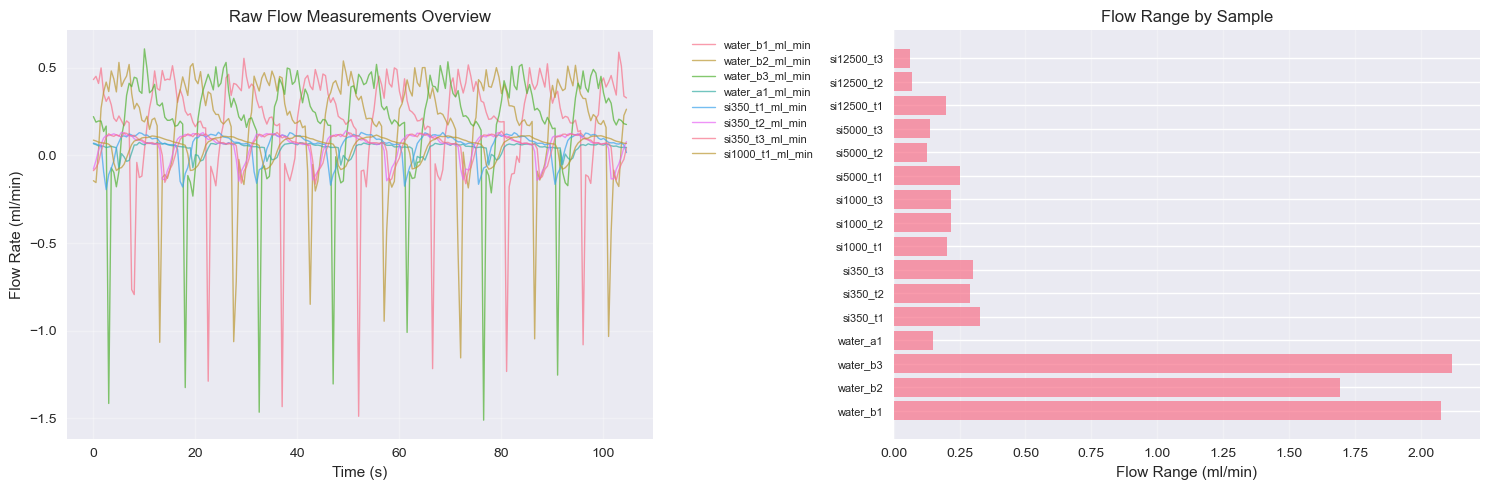


📋 Sample Statistics:
        Sample   Mean    Std    Min    Max  Range
0     water_b1  0.205  0.328 -1.489  0.589  2.078
1     water_b2  0.193  0.311 -1.156  0.539  1.695
2     water_b3  0.197  0.338 -1.511  0.608  2.119
3     water_a1  0.043  0.033 -0.076  0.075  0.151
4     si350_t1  0.062  0.075 -0.195  0.132  0.327
5     si350_t2  0.062  0.072 -0.147  0.141  0.288
6     si350_t3  0.060  0.073 -0.164  0.138  0.302
7    si1000_t1  0.058  0.059 -0.086  0.116  0.203
8    si1000_t2  0.064  0.063 -0.092  0.127  0.219
9    si1000_t3  0.064  0.064 -0.094  0.124  0.218
10   si5000_t1  0.043  0.050 -0.129  0.121  0.250
11   si5000_t2  0.062  0.038 -0.027  0.100  0.127
12   si5000_t3  0.062  0.029 -0.039  0.098  0.137
13  si12500_t1  0.060  0.045 -0.095  0.104  0.199
14  si12500_t2  0.075  0.023  0.029  0.100  0.071
15  si12500_t3  0.073  0.019  0.032  0.095  0.063


In [388]:
# Quick data overview
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: All flow signals overview
for i, col in enumerate(flow_columns[:8]):  # Show first 8 for clarity
    ax1.plot(df['time_s'], df[col], alpha=0.7, linewidth=1, label=col)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Flow Rate (ml/min)')
ax1.set_title('Raw Flow Measurements Overview')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Panel 2: Sample statistics
sample_stats = []
for col in flow_columns:
    stats = {
        'Sample': col.replace('_ml_min', ''),
        'Mean': df[col].mean(),
        'Std': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Range': df[col].max() - df[col].min()
    }
    sample_stats.append(stats)

stats_df = pd.DataFrame(sample_stats)
ax2.barh(range(len(stats_df)), stats_df['Range'], alpha=0.7)
ax2.set_yticks(range(len(stats_df)))
ax2.set_yticklabels(stats_df['Sample'], fontsize=8)
ax2.set_xlabel('Flow Range (ml/min)')
ax2.set_title('Flow Range by Sample')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Display sample info table
print("\n📋 Sample Statistics:")
print(stats_df.round(3))

# 🔄 STEP 2: Cycle Detection Algorithm

🔍 Cycle Detection Results for water_b1_ml_min:
   📊 6 cycles detected
   ⏱️ Average duration: 14.5s
   📈 Average amplitude: 1.877 ml/min


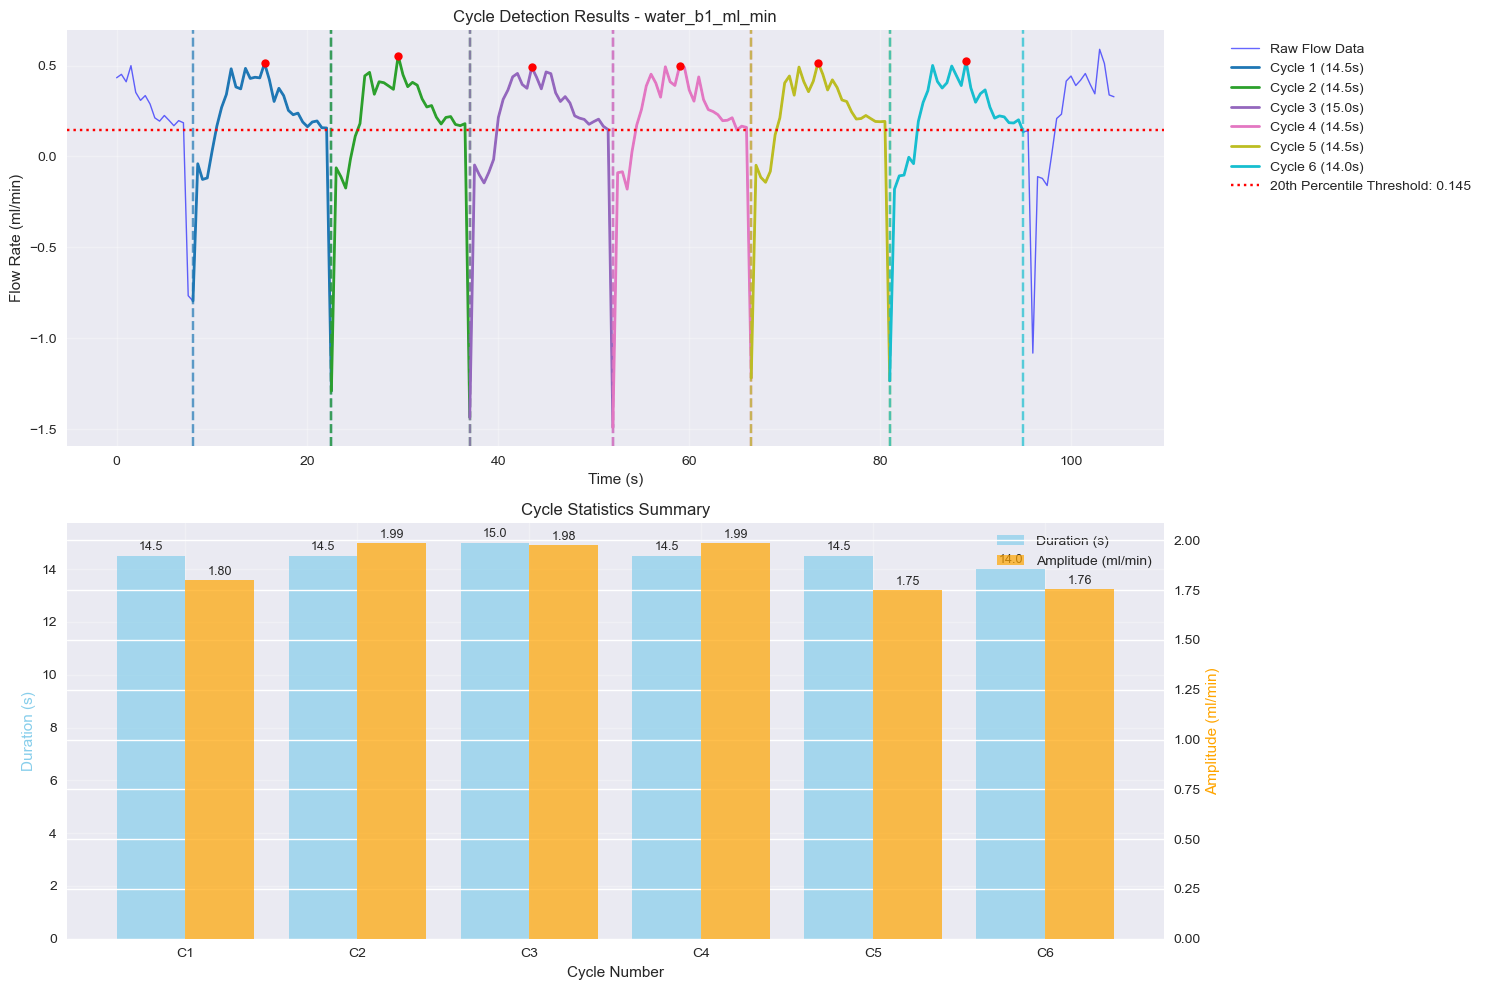

In [389]:
def find_flow_cycles(time, flow, min_prominence=0.01, min_distance_sec=0.5):
    """
    Find repetitive cycles in flow data by detecting gradient sign changes with low flow values.
    
    Algorithm:
    1. Check all data for each sample from beginning to end
    2. Calculate gradient (flow change) between consecutive points
    3. Find critical points where gradient sign changes AND flow value is in lowest 20%
    4. Ensure critical points are at least 8 seconds apart
    5. Label these points as cycle start/end boundaries
    
    Parameters:
    - time: array of time values (seconds)
    - flow: array of flow values (ml/min)
    - min_prominence: not used in new algorithm, kept for compatibility
    - min_distance_sec: not used (fixed at 8.0 seconds), kept for compatibility
    
    Returns:
    - cycles: list of dictionaries containing cycle information including actual data
    """
    # Remove NaN values
    valid_mask = ~np.isnan(flow)
    valid_time = time[valid_mask]
    valid_flow = flow[valid_mask]
    
    if len(valid_flow) < 10:  # Need minimum points for analysis
        return []
    
    # Calculate gradient (flow change) between consecutive points
    gradients = np.diff(valid_flow)  # gradient[i] = flow[i+1] - flow[i]
    
    if len(gradients) < 5:
        return []
    
    # Calculate 20th percentile of flow values for threshold
    flow_20th_percentile = np.percentile(valid_flow, 20)
    
    # Find critical points where gradient sign changes AND flow value is in lowest 20%
    critical_points = []
    last_critical_time = -float('inf')  # Track time of last critical point
    
    # Start from the second point (index 1) since we need gradient
    for i in range(1, len(gradients)):
        # Check if gradient sign changes
        if gradients[i-1] * gradients[i] < 0:  # Sign change detected
            
            # Check if flow rate value is in lowest 20%
            current_flow = valid_flow[i]
            current_time = valid_time[i]
            
            if current_flow <= flow_20th_percentile:
                # Check if enough time has passed since the last critical point (minimum 8 seconds)
                if current_time - last_critical_time >= 8.0:
                    critical_points.append({
                        'index': i,  # Index in valid arrays
                        'time': current_time,
                        'flow': current_flow,
                        'gradient_before': gradients[i-1],
                        'gradient_after': gradients[i],
                        'flow_threshold': flow_20th_percentile
                    })
                    last_critical_time = current_time
    
    if len(critical_points) < 2:
        return []
    
    # Create cycles from consecutive critical points
    cycles = []
    
    for i in range(len(critical_points) - 1):
        start_cp = critical_points[i]
        end_cp = critical_points[i + 1]
        
        start_idx = start_cp['index']
        end_idx = end_cp['index']
        
        # Find peak within this cycle
        cycle_flow_segment = valid_flow[start_idx:end_idx+1]
        peak_relative_idx = np.argmax(cycle_flow_segment)
        peak_idx = start_idx + peak_relative_idx
        
        # Extract cycle data (time and flow arrays for this specific cycle)
        cycle_mask = (valid_time >= start_cp['time']) & (valid_time <= end_cp['time'])
        cycle_time_data = valid_time[cycle_mask]
        cycle_flow_data = valid_flow[cycle_mask]
        
        # Calculate cycle statistics
        duration = end_cp['time'] - start_cp['time']
        amplitude = valid_flow[peak_idx] - min(start_cp['flow'], end_cp['flow'])
        
        cycle_info = {
            'cycle_number': len(cycles) + 1,
            'start_time': start_cp['time'],
            'peak_time': valid_time[peak_idx],
            'end_time': end_cp['time'],
            'start_idx': start_idx,
            'peak_idx': peak_idx,
            'end_idx': end_idx,
            'duration': duration,
            'start_flow': start_cp['flow'],
            'peak_flow': valid_flow[peak_idx],
            'end_flow': end_cp['flow'],
            'amplitude': amplitude,
            # Cycle data arrays
            'cycle_time': cycle_time_data.copy(),  # Time array for this cycle
            'cycle_flow': cycle_flow_data.copy(),  # Flow array for this cycle
            'data_points': len(cycle_time_data),   # Number of data points in cycle
            # New gradient-based information
            'start_gradient_change': (start_cp['gradient_before'], start_cp['gradient_after']),
            'end_gradient_change': (end_cp['gradient_before'], end_cp['gradient_after']),
            'start_flow_value': start_cp['flow'],
            'end_flow_value': end_cp['flow'],
            'flow_threshold': flow_20th_percentile
        }
        cycles.append(cycle_info)
    
    return cycles

def get_cycle_data(sample_column, cycle_number, df=df, time=None):
    """
    Retrieve the time and flow data for a specific cycle of a specific sample.
    
    Parameters:
    - sample_column: string, column name in DataFrame (e.g., 'water_b1_ml_min')
    - cycle_number: int, cycle number (1-indexed)
    - df: DataFrame containing the data
    - time: time array (if None, uses df['time_s'])
    
    Returns:
    - dict with cycle info including time and flow arrays, or None if not found
    """
    if time is None:
        time = df['time_s'].values
    
    if sample_column not in df.columns:
        print(f"Error: Column '{sample_column}' not found in DataFrame")
        return None
    
    flow_data = df[sample_column].values
    
    # Find all cycles for this sample
    cycles = find_flow_cycles(time, flow_data, min_prominence=0.01, min_distance_sec=0.5)
    
    if cycle_number < 1 or cycle_number > len(cycles):
        print(f"Error: Cycle {cycle_number} not found. Sample '{sample_column}' has {len(cycles)} cycles.")
        return None
    
    # Return the requested cycle (convert to 0-indexed)
    return cycles[cycle_number - 1]

def visualize_cycle_detection(time, flow, cycles, sample_name):
    """Create comprehensive cycle detection visualization"""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Top panel: Full signal with detected cycles
    ax1.plot(time, flow, 'b-', alpha=0.6, linewidth=1, label='Raw Flow Data')
    
    # Highlight each cycle with different colors
    colors = plt.cm.tab10(np.linspace(0, 1, len(cycles)))
    
    for i, cycle in enumerate(cycles):
        cycle_time = cycle['cycle_time']
        cycle_flow = cycle['cycle_flow']
        
        ax1.plot(cycle_time, cycle_flow, color=colors[i], linewidth=2, 
                label=f'Cycle {i+1} ({cycle["duration"]:.1f}s)')
        
        # Mark cycle boundaries
        ax1.axvline(cycle['start_time'], color=colors[i], linestyle='--', alpha=0.7)
        ax1.axvline(cycle['end_time'], color=colors[i], linestyle='--', alpha=0.7)
        
        # Mark peaks
        ax1.plot(cycle['peak_time'], cycle['peak_flow'], 'ro', markersize=6)
    
    # Add threshold line
    if cycles:
        ax1.axhline(cycles[0]['flow_threshold'], color='red', linestyle=':', 
                   label=f'20th Percentile Threshold: {cycles[0]["flow_threshold"]:.3f}')
    
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Flow Rate (ml/min)')
    ax1.set_title(f'Cycle Detection Results - {sample_name}')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Bottom panel: Cycle statistics
    if cycles:
        cycle_data = {
            'Cycle': [f"C{c['cycle_number']}" for c in cycles],
            'Duration (s)': [c['duration'] for c in cycles],
            'Amplitude': [c['amplitude'] for c in cycles],
            'Peak Flow': [c['peak_flow'] for c in cycles],
            'Data Points': [c['data_points'] for c in cycles]
        }
        
        cycle_df = pd.DataFrame(cycle_data)
        
        # Plot cycle statistics
        x_pos = range(len(cycles))
        
        ax2_twin = ax2.twinx()
        
        bars1 = ax2.bar([x - 0.2 for x in x_pos], cycle_df['Duration (s)'], 
                       width=0.4, label='Duration (s)', alpha=0.7, color='skyblue')
        bars2 = ax2_twin.bar([x + 0.2 for x in x_pos], cycle_df['Amplitude'], 
                            width=0.4, label='Amplitude (ml/min)', alpha=0.7, color='orange')
        
        ax2.set_xlabel('Cycle Number')
        ax2.set_ylabel('Duration (s)', color='skyblue')
        ax2_twin.set_ylabel('Amplitude (ml/min)', color='orange')
        ax2.set_title('Cycle Statistics Summary')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(cycle_df['Cycle'])
        ax2.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
            ax2.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.1, 
                    f'{cycle_df["Duration (s)"].iloc[i]:.1f}', 
                    ha='center', va='bottom', fontsize=9)
            ax2_twin.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.01, 
                         f'{cycle_df["Amplitude"].iloc[i]:.2f}', 
                         ha='center', va='bottom', fontsize=9)
        
        # Combine legends
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Test cycle detection on a sample
sample_name = 'water_b1_ml_min'
time_data = df['time_s'].values
flow_data = df[sample_name].values

cycles = find_flow_cycles(time_data, flow_data)

print(f"🔍 Cycle Detection Results for {sample_name}:")
print(f"   📊 {len(cycles)} cycles detected")
if cycles:
    avg_duration = np.mean([c['duration'] for c in cycles])
    avg_amplitude = np.mean([c['amplitude'] for c in cycles])
    print(f"   ⏱️ Average duration: {avg_duration:.1f}s")
    print(f"   📈 Average amplitude: {avg_amplitude:.3f} ml/min")

# Visualize detection results
fig = visualize_cycle_detection(time_data, flow_data, cycles, sample_name)

In [390]:
def apply_savitzky_filter(cycle_data, window_length=11, polyorder=3):
    """
    Apply Savitzky-Golay filter to cycle data for smoothing.
    
    Parameters:
    - cycle_data: dict containing cycle information with 'cycle_time' and 'cycle_flow' keys
    - window_length: length of the filter window (must be odd)
    - polyorder: order of the polynomial used to fit the samples
    
    Returns:
    - dict with original and filtered data plus smoothing parameters
    """
    if cycle_data is None:
        return None
    
    time_orig = cycle_data['cycle_time']
    flow_orig = cycle_data['cycle_flow']
    
    # Ensure window_length is odd and reasonable
    if window_length % 2 == 0:
        window_length += 1
    
    # Ensure window_length is not larger than data
    window_length = min(window_length, len(flow_orig))
    if window_length < 3:
        window_length = 3
    
    # Ensure polyorder is less than window_length
    polyorder = min(polyorder, window_length - 1)
    
    # Apply Savitzky-Golay filter
    try:
        from scipy.signal import savgol_filter
        flow_smooth = savgol_filter(flow_orig, window_length, polyorder)
    except:
        # Fallback to simple moving average
        flow_smooth = flow_orig.copy()
        for i in range(len(flow_smooth)):
            start_idx = max(0, i - window_length//2)
            end_idx = min(len(flow_smooth), i + window_length//2 + 1)
            flow_smooth[i] = np.mean(flow_orig[start_idx:end_idx])
    
    filtered_data = {
        'time_orig': time_orig.copy(),
        'flow_orig': flow_orig.copy(),
        'flow_smooth': flow_smooth,
        'cycle_data': cycle_data,
        'smoothing_params': {
            'window_length': window_length,
            'polyorder': polyorder
        }
    }
    
    return filtered_data

def detect_cycle_phases(filtered_data):
    """
    Detect phases in cycle data using time-based boundaries and peak detection.
    Based on the method from fit_segments_to_cycle but simplified for phase detection only.
    
    Parameters:
    - filtered_data: dict from apply_savitzky_filter() containing smoothed data
    
    Returns:
    - dict with phase boundaries and information
    """
    if filtered_data is None:
        return None
    
    time_orig = filtered_data['time_orig']
    flow_smooth = filtered_data['flow_smooth']
    
    # Find indices for time-based boundaries
    def find_time_index(target_time):
        """Find the index closest to the target time"""
        return np.argmin(np.abs(time_orig - target_time))
    
    # Segment boundaries based on time
    seg1_end_time = time_orig[0] + 1.5  # 1.5 seconds from start
    seg4_start_time = time_orig[-1] - 1.5  # 1.5 seconds before end
    
    # Find peak (maximum flow) in the data
    peak_idx = np.argmax(flow_smooth)
    peak_time = time_orig[peak_idx]
    
    # Convert times to indices
    seg1_end_idx = find_time_index(seg1_end_time)
    seg4_start_idx = find_time_index(seg4_start_time)
    
    # Ensure peak is between seg1_end and seg4_start
    if peak_idx <= seg1_end_idx:
        seg1_end_idx = max(1, peak_idx - 1)
    elif peak_idx >= seg4_start_idx:
        seg4_start_idx = min(len(time_orig) - 2, peak_idx + 1)
    
    # Phase boundaries
    phase_boundaries = {
        'phase1_start': 0,
        'phase1_end': seg1_end_idx,  # Initial Ramp (0-1.5s)
        'phase2_start': seg1_end_idx,
        'phase2_end': peak_idx,  # Rise to Peak (1.5s-peak)
        'phase3_start': peak_idx,
        'phase3_end': seg4_start_idx,  # Peak to Final (peak-1.5s before end)
        'phase4_start': seg4_start_idx,
        'phase4_end': len(time_orig) - 1,  # Final Descent (1.5s before end-end)
        'peak_idx': peak_idx,
        'peak_time': peak_time
    }
    
    return phase_boundaries

print("✅ Phase detection functions defined successfully")

✅ Phase detection functions defined successfully


# 🧮 STEP 3: Physics-Based Rheometry Pipeline

In [391]:
class PeristalticRheometer:
    """
    Complete physics-based rheometry pipeline for peristaltic pump analysis.
    
    Implements enhanced workflow using:
    1. Gradient-based cycle detection (find_flow_cycles)
    2. Time-based phase detection with (A+B*t)*exp(-t/tau) fitting
    3. Geometric flow computation and material property extraction
    """
    
    def __init__(self, omega, D_axis, d_int, L_c, E, eta_tube):
        """
        Initialize rheometer with pump and tube parameters.
        
        Parameters:
        -----------
        omega : float
            Rotation speed (rad/s)
        D_axis : float  
            Pump axis diameter (m)
        d_int : float
            Tube internal diameter (m)
        L_c : float
            Contact length (m)
        E : float
            Tube elastic modulus (Pa)
        eta_tube : float
            Tube internal friction (Pa·s)
        """
        self.omega = omega
        self.D_axis = D_axis 
        self.d_int = d_int
        self.L_c = L_c
        self.E = E
        self.eta_tube = eta_tube
        
        # Calculate derived parameters
        self.A_int = np.pi * d_int**2 / 4  # Internal area
        self.alpha = L_c / self.A_int      # Geometric factor
        
        # Storage for intermediate results
        self.results = {}
        
    def compute_geometric_flow(self):
        """Step 2: Compute kinematic flow contribution"""
        Q_geom = self.omega * self.D_axis * self.d_int**2 / 8
        self.results['Q_geom'] = Q_geom
        return Q_geom
        
    def compute_residual_flow(self, Q_measured):
        """Step 3: Isolate viscoelastic contribution"""
        Q_geom = self.results.get('Q_geom', self.compute_geometric_flow())
        Q_res = Q_measured - Q_geom
        self.results['Q_res'] = Q_res
        return Q_res
        
    def analyze_single_cycle_phases(self, cycle_data, smoothing_window=11, polyorder=3, enable_filtering=True):
        """
        Analyze phases in a single cycle using time-based boundaries.
        
        Parameters:
        - cycle_data: dict containing 'cycle_time' and 'cycle_flow' arrays
        - smoothing_window: Savitzky-Golay filter window length
        - polyorder: Savitzky-Golay filter polynomial order
        - enable_filtering: bool, whether to apply Savitzky-Golay filter (True) or use raw data (False)
        
        Returns:
        - dict with phase analysis results
        """
        # Conditionally apply Savitzky-Golay smoothing
        if enable_filtering:
            filtered_data = apply_savitzky_filter(cycle_data, smoothing_window, polyorder)
        else:
            # Use raw data without filtering
            filtered_data = {
                'time_orig': cycle_data['cycle_time'].copy(),
                'flow_orig': cycle_data['cycle_flow'].copy(),
                'flow_smooth': cycle_data['cycle_flow'].copy(),  # Use raw data as "smooth"
                'cycle_data': cycle_data,
                'smoothing_params': {
                    'window_length': 0,  # Indicate no filtering
                    'polyorder': 0,
                    'filtering_enabled': False
                }
            }

        if filtered_data is None:
            return None
        
        # Detect phases using time-based boundaries
        phase_boundaries = detect_cycle_phases(filtered_data)
        
        if phase_boundaries is None:
            return None
            
        # Extract phases 2 and 3 for viscosity fitting
        time_orig = filtered_data['time_orig']
        flow_smooth = filtered_data['flow_smooth']
        
        phase2_start = phase_boundaries['phase2_start']
        phase2_end = phase_boundaries['phase2_end']
        phase3_start = phase_boundaries['phase3_start']
        phase3_end = phase_boundaries['phase3_end']
        
        # Combine phase 2 and 3 data for fitting
        combined_indices = list(range(phase2_start, phase2_end+1)) + list(range(phase3_start, phase3_end+1))
        
        if len(combined_indices) < 4:  # Need minimum points for fitting
            return None
            
        phase_results = {
            'filtered_data': filtered_data,
            'phase_boundaries': phase_boundaries,
            'combined_phase_indices': combined_indices,
            'phase2_indices': list(range(phase2_start, phase2_end+1)),
            'phase3_indices': list(range(phase3_start, phase3_end+1))
        }
        
        return phase_results
        
    def fit_viscosity_to_cycle(self, phase_results):
        """
        Fit (A+B*t)*exp(-t/tau) function to phases 2 and 3 of a single cycle.
        
        Parameters:
        - phase_results: dict from analyze_single_cycle_phases()
        
        Returns:
        - dict with viscosity fitting results
        """
        if phase_results is None:
            return None
            
        from scipy.optimize import curve_fit
        
        filtered_data = phase_results['filtered_data']
        combined_indices = phase_results['combined_phase_indices']
        
        time_orig = filtered_data['time_orig']
        flow_smooth = filtered_data['flow_smooth']
        
        # Extract combined time and flow data
        t_combined = time_orig[combined_indices]
        flow_combined = flow_smooth[combined_indices]
        
        # Normalize time to start from 0
        t_norm = t_combined - t_combined[0]
        
        # Define the fitting function: (A + B*t) * exp(-t/tau)
        def viscosity_function(t, A, B, tau):
            return (A + B * t) * np.exp(-t / tau)
        
        try:
            # Set reasonable initial guesses and bounds
            max_flow = np.max(flow_combined)
            A_init = max_flow
            B_init = 0.0
            tau_init = (t_norm[-1] - t_norm[0]) / 3
            
            initial_guess = [A_init, B_init, tau_init]
            lower_bounds = [-10*abs(max_flow), -10*abs(max_flow), 0.1]
            upper_bounds = [10*abs(max_flow), 10*abs(max_flow), 100.0]
            
            # Fit the function
            popt, pcov = curve_fit(viscosity_function, t_norm, flow_combined, 
                                  p0=initial_guess, bounds=(lower_bounds, upper_bounds),
                                  maxfev=2000)
            
            A_fit, B_fit, tau_fit = popt
            
            # Calculate fitted values and quality metrics
            flow_fitted = viscosity_function(t_norm, A_fit, B_fit, tau_fit)
            
            # Calculate R-squared
            ss_res = np.sum((flow_combined - flow_fitted) ** 2)
            ss_tot = np.sum((flow_combined - np.mean(flow_combined)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            
            # Calculate parameter uncertainties
            param_errors = np.sqrt(np.diag(pcov))
            A_error, B_error, tau_error = param_errors
            
            fit_results = {
                'A': A_fit,
                'B': B_fit, 
                'tau': tau_fit,
                'A_error': A_error,
                'B_error': B_error,
                'tau_error': tau_error,
                'r_squared': r_squared,
                'n_points': len(t_combined),
                'time_span': t_norm[-1] - t_norm[0],
                't_norm': t_norm,
                'flow_combined': flow_combined,
                'flow_fitted': flow_fitted
            }
            
        except Exception as e:
            # Return NaN results if fitting fails
            fit_results = {
                'A': np.nan,
                'B': np.nan,
                'tau': np.nan,
                'A_error': np.nan,
                'B_error': np.nan,
                'tau_error': np.nan,
                'r_squared': 0,
                'n_points': len(t_combined),
                'time_span': t_norm[-1] - t_norm[0] if len(t_norm) > 0 else 0,
                't_norm': t_norm,
                'flow_combined': flow_combined,
                'flow_fitted': np.full_like(flow_combined, np.nan)
            }
        
        return fit_results
        
    def compute_material_viscosity(self, tau):
        """Calculate fluid viscosity from relaxation time"""
        if tau <= 0 or np.isnan(tau):
            return np.nan
            
        mu = (self.E * tau - self.eta_tube) / self.alpha
        return mu
        
    def analyze_all_cycles(self, time, flow_ml_min, sample_name="Sample", enable_filtering=True):
        """
        Analyze all detected cycles individually and return comprehensive results.
        
        Parameters:
        - time: array of time values (s)
        - flow_ml_min: array of flow rate measurements (ml/min)
        - sample_name: string identifier for the sample
        - enable_filtering: bool, whether to apply Savitzky-Golay filtering (default True)
        
        Returns:
        - dict with analysis results for all cycles
        """
        
        # Step 1: Detect all cycles
        all_cycles = find_flow_cycles(time, flow_ml_min)
        
        if not all_cycles:
            print(f"No cycles detected for {sample_name}")
            return None
            
        print(f"Analyzing {len(all_cycles)} cycles for {sample_name}")
        
        # Step 2: Geometric flow computation
        Q_geom = self.compute_geometric_flow()
        
        # Step 3: Analyze each cycle
        cycle_analyses = []
        
        for i, cycle_data in enumerate(all_cycles):
            print(f"  Processing cycle {i+1}/{len(all_cycles)}...")
            
            # Phase analysis
            phase_results = self.analyze_single_cycle_phases(cycle_data, enable_filtering=enable_filtering)
            
            # Viscosity fitting
            viscosity_fit = self.fit_viscosity_to_cycle(phase_results) if phase_results else None
            
            # Calculate viscosity
            if viscosity_fit and not np.isnan(viscosity_fit['tau']):
                tau = viscosity_fit['tau']
                mu = self.compute_material_viscosity(tau)
                mu_mPa_s = mu * 1000 if not np.isnan(mu) else np.nan
            else:
                tau = np.nan
                mu = np.nan
                mu_mPa_s = np.nan
            
            cycle_analysis = {
                'cycle_number': i + 1,
                'cycle_data': cycle_data,
                'phase_results': phase_results,
                'viscosity_fit': viscosity_fit,
                'tau': tau,
                'viscosity_Pa_s': mu,
                'viscosity_mPa_s': mu_mPa_s,
                'fit_quality': viscosity_fit['r_squared'] if viscosity_fit else 0
            }
            
            cycle_analyses.append(cycle_analysis)
        
        # Compile comprehensive results
        analysis_results = {
            'sample_name': sample_name,
            'input_parameters': {
                'omega': self.omega,
                'D_axis': self.D_axis,
                'd_int': self.d_int,
                'L_c': self.L_c,
                'E': self.E,
                'eta_tube': self.eta_tube,
                'alpha': self.alpha,
                'A_int': self.A_int
            },
            'cycle_detection': {
                'n_cycles_detected': len(all_cycles),
                'all_cycles': all_cycles
            },
            'flow_analysis': {
                'Q_geom_m3s': Q_geom,
                'Q_geom_ml_min': Q_geom * 60 * 1e6
            },
            'cycle_analyses': cycle_analyses,
            'raw_data': {
                'time': time,
                'flow_ml_min': flow_ml_min
            }
        }
        
        # Store results
        self.results.update(analysis_results)
        
        return analysis_results
        
    def create_comprehensive_visualization(self, analysis_results, show_plots=True):
        """
        Create comprehensive visualization showing all cycles with fitted curves.
        
        Parameters:
        - analysis_results: dict from analyze_all_cycles()
        - show_plots: bool, whether to display plots
        
        Returns:
        - list of figure objects
        """
        if analysis_results is None:
            print("No analysis results to visualize")
            return []
            
        figures = []
        sample_name = analysis_results['sample_name']
        
        # 1. Cycle detection overview
        time = analysis_results['raw_data']['time']
        flow_ml_min = analysis_results['raw_data']['flow_ml_min']
        all_cycles = analysis_results['cycle_detection']['all_cycles']
        
        if show_plots:
            fig1 = visualize_cycle_detection(time, flow_ml_min, all_cycles, sample_name)
            figures.append(fig1)
        
        # 2. All cycles with fitted curves
        if show_plots:
            cycle_analyses = analysis_results['cycle_analyses']
            n_cycles = len(cycle_analyses)
            
            # Create figure with subplots for each cycle
            n_cols = min(3, n_cycles)
            n_rows = int(np.ceil(n_cycles / n_cols))
            
            fig2, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
            if n_cycles == 1:
                axes = [axes]
            elif n_rows == 1:
                axes = [axes]
            else:
                axes = axes.flatten()
            
            for i, cycle_analysis in enumerate(cycle_analyses):
                ax = axes[i] if i < len(axes) else None
                if ax is None:
                    continue
                    
                cycle_data = cycle_analysis['cycle_data']
                viscosity_fit = cycle_analysis['viscosity_fit']
                
                # Plot original cycle data
                cycle_time = cycle_data['cycle_time']
                cycle_flow = cycle_data['cycle_flow']
                
                ax.plot(cycle_time, cycle_flow, 'b-', alpha=0.7, linewidth=1, label='Data')
                
                # Plot fitted curve if available
                if viscosity_fit and not np.any(np.isnan(viscosity_fit['flow_fitted'])):
                    phase_results = cycle_analysis['phase_results']
                    if phase_results:
                        filtered_data = phase_results['filtered_data']
                        combined_indices = phase_results['combined_phase_indices']
                        
                        # Get time for fitted data
                        time_orig = filtered_data['time_orig']
                        t_combined = time_orig[combined_indices]
                        
                        # Plot fitted curve
                        ax.plot(t_combined, viscosity_fit['flow_fitted'], 'r-', linewidth=2, 
                               label=f'Fit: τ={viscosity_fit["tau"]:.2f}s, R²={viscosity_fit["r_squared"]:.3f}')
                        
                        # Highlight phases 2 and 3
                        phase2_indices = phase_results['phase2_indices']
                        phase3_indices = phase_results['phase3_indices']
                        
                        if phase2_indices:
                            ax.plot(time_orig[phase2_indices], filtered_data['flow_smooth'][phase2_indices], 
                                   'orange', linewidth=2, alpha=0.7, label='Phase 2')
                        if phase3_indices:
                            ax.plot(time_orig[phase3_indices], filtered_data['flow_smooth'][phase3_indices], 
                                   'green', linewidth=2, alpha=0.7, label='Phase 3')
                
                ax.set_xlabel('Time (s)')
                ax.set_ylabel('Flow Rate (ml/min)')
                ax.set_title(f'Cycle {i+1}: μ={cycle_analysis["viscosity_mPa_s"]:.1f} mPa·s' 
                           if not np.isnan(cycle_analysis["viscosity_mPa_s"]) else f'Cycle {i+1}: Fit Failed')
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)
            
            # Hide unused subplots
            for j in range(len(cycle_analyses), len(axes)):
                axes[j].set_visible(False)
            
            plt.suptitle(f'All Cycles with Viscosity Fits - {sample_name}', fontsize=16)
            plt.tight_layout()
            plt.show()
            figures.append(fig2)
        
        # 3. Viscosity summary table
        if show_plots:
            cycle_analyses = analysis_results['cycle_analyses']
            
            print(f"\n📊 Viscosity Results Summary for {sample_name}")
            print("=" * 80)
            
            # Create summary data
            summary_data = []
            valid_viscosities = []
            
            for cycle_analysis in cycle_analyses:
                cycle_num = cycle_analysis['cycle_number']
                tau = cycle_analysis['tau']
                mu_mPa_s = cycle_analysis['viscosity_mPa_s']
                r_squared = cycle_analysis['fit_quality']
                
                # Duration and amplitude from cycle data
                cycle_data = cycle_analysis['cycle_data']
                duration = cycle_data['duration']
                amplitude = cycle_data['amplitude']
                
                summary_data.append({
                    'Cycle': cycle_num,
                    'Duration (s)': f"{duration:.2f}",
                    'Amplitude (ml/min)': f"{amplitude:.3f}",
                    'τ (s)': f"{tau:.2f}" if not np.isnan(tau) else "Failed",
                    'μ (mPa·s)': f"{mu_mPa_s:.1f}" if not np.isnan(mu_mPa_s) else "Failed",
                    'R²': f"{r_squared:.3f}" if r_squared > 0 else "Failed"
                })
                
                if not np.isnan(mu_mPa_s):
                    valid_viscosities.append(mu_mPa_s)
            
            # Display table
            import pandas as pd
            summary_df = pd.DataFrame(summary_data)
            print(summary_df.to_string(index=False))
            
            # Display statistics
            if valid_viscosities:
                print(f"\n📈 Statistics:")
                print(f"   Valid measurements: {len(valid_viscosities)}/{len(cycle_analyses)} cycles")
                print(f"   Mean viscosity: {np.mean(valid_viscosities):.1f} ± {np.std(valid_viscosities):.1f} mPa·s")
                print(f"   Range: {np.min(valid_viscosities):.1f} - {np.max(valid_viscosities):.1f} mPa·s")
                print(f"   CV: {100*np.std(valid_viscosities)/np.mean(valid_viscosities):.1f}%")
            else:
                print(f"\n❌ No valid viscosity measurements obtained")
        
        return figures


print("✅ Enhanced PeristalticRheometer class defined successfully")

✅ Enhanced PeristalticRheometer class defined successfully


In [392]:
def visualize_rheometry_analysis(rheometer, cycle_data, sample_name):
    """
    Create comprehensive visualization of the 11-step rheometry analysis.
    """
    
    results = rheometer.results
    time = cycle_data['cycle_time'] 
    flow_ml_min = cycle_data['cycle_flow']
    
    # Create multi-panel figure
    fig = plt.figure(figsize=(20, 16))
    
    # Panel 1: Raw data and geometric flow (Steps 1-2)
    ax1 = plt.subplot(4, 3, 1)
    ax1.plot(time, flow_ml_min, 'b-', linewidth=2, label='Measured Flow')
    Q_geom_ml_min = results['Q_geom'] * 60 * 1e6  # Convert back to ml/min
    ax1.axhline(Q_geom_ml_min, color='red', linestyle='--', linewidth=2, 
               label=f'Q_geom = {Q_geom_ml_min:.3f} ml/min')
    ax1.set_ylabel('Flow (ml/min)')
    ax1.set_title('Step 1-2: Raw Data & Geometric Flow')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Residual flow (Step 3)
    ax2 = plt.subplot(4, 3, 2)
    Q_res_ml_min = results['Q_res'] * 60 * 1e6  # Convert to ml/min
    ax2.plot(time, Q_res_ml_min, 'g-', linewidth=2, label='Residual Flow')
    ax2.axhline(0, color='k', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Q_res (ml/min)')
    ax2.set_title('Step 3: Residual Flow')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: Phase segmentation (Step 4)
    ax3 = plt.subplot(4, 3, 3)
    ax3.plot(time, Q_res_ml_min, 'k-', alpha=0.3, label='Q_res')
    
    phases = results['phases']
    phase_colors = {'engaging': 'blue', 'compressing': 'orange', 
                   'relieving': 'red', 'disengaging': 'purple'}
    
    for phase_name, indices in phases.items():
        if indices:
            phase_times = time[indices]
            phase_flows = Q_res_ml_min[indices]
            ax3.scatter(phase_times, phase_flows, c=phase_colors[phase_name], 
                       alpha=0.7, s=20, label=f'{phase_name.title()} ({len(indices)} pts)')
    
    ax3.set_ylabel('Q_res (ml/min)')
    ax3.set_title('Step 4: Phase Segmentation')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Panel 4: Phase III selection (Step 5)
    ax4 = plt.subplot(4, 3, 4)
    phase_III = results['phase_III']
    t_III = phase_III['time']
    Q_III_ml_min = phase_III['flow'] * 60 * 1e6
    
    ax4.plot(time, Q_res_ml_min, 'k-', alpha=0.3, label='Full Residual')
    ax4.plot(t_III, Q_III_ml_min, 'red', linewidth=3, label='Phase III (Relieving)')
    ax4.set_ylabel('Q_res (ml/min)')
    ax4.set_title('Step 5: Phase III Selection')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Panel 5: Steady-state identification (Step 6)
    ax5 = plt.subplot(4, 3, 5)
    ax5.plot(t_III, Q_III_ml_min, 'red', linewidth=2, label='Phase III')
    
    steady = results['steady_state']
    Q_ss_ml_min = steady['Q_res_ss'] * 60 * 1e6
    ax5.axhline(Q_ss_ml_min, color='blue', linestyle='--', linewidth=2,
               label=f'Q_ss = {Q_ss_ml_min:.4f} ml/min')
    
    # Highlight steady-state region
    n_steady = steady['n_points']
    if len(t_III) >= n_steady:
        ax5.fill_between(t_III[-n_steady:], Q_III_ml_min[-n_steady:], 
                        alpha=0.3, color='blue', label=f'Steady region ({n_steady} pts)')
    
    ax5.set_ylabel('Q_res (ml/min)')
    ax5.set_title('Step 6: Steady-State ID')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Panel 6: Geometric coupling Γ (Step 7)
    ax6 = plt.subplot(4, 3, 6)
    Gamma = results['Gamma']
    omega = rheometer.omega
    
    # Create a simple bar plot for Gamma
    ax6.bar(['Γ'], [Gamma * 1e6], color='purple', alpha=0.7)  # Convert to mm³/rad
    ax6.set_ylabel('Γ (mm³/rad)')
    ax6.set_title(f'Step 7: Geometric Coupling\nΓ = {Gamma*1e6:.2f} mm³/rad')
    ax6.grid(True, alpha=0.3)
    
    # Add calculation details as text
    ax6.text(0, Gamma*1e6*1.1, f'ω = {omega:.3f} rad/s\nQ_ss = {Q_ss_ml_min:.4f} ml/min', 
            ha='center', va='bottom', fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Panel 7: Offset removal (Step 8)
    ax7 = plt.subplot(4, 3, 7)
    Q_tilde_ml_min = results['Q_tilde'] * 60 * 1e6
    
    ax7.plot(t_III, Q_III_ml_min, 'red', alpha=0.5, label='Phase III')
    ax7.plot(t_III, Q_tilde_ml_min, 'blue', linewidth=2, label='Q̃ (offset removed)')
    ax7.axhline(0, color='k', linestyle=':', alpha=0.5)
    ax7.set_ylabel('Flow (ml/min)')
    ax7.set_title('Step 8: Offset Removal')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # Panel 8: Relaxation time fitting (Step 9)
    ax8 = plt.subplot(4, 3, 8)
    
    # Plot experimental data
    t_norm = t_III - t_III[0]
    ax8.plot(t_norm, Q_tilde_ml_min, 'bo', alpha=0.7, label='Experimental')
    
    # Plot fitted exponential
    relaxation_fit = results['relaxation_fit']
    tau = relaxation_fit['tau']
    A = relaxation_fit['A']
    r_squared = relaxation_fit['r_squared']
    
    # Generate smooth fit curve
    t_fit = np.linspace(0, t_norm[-1], 100)
    Q_fit = A * np.exp(-t_fit / tau) * 60 * 1e6  # Convert to ml/min
    ax8.plot(t_fit, Q_fit, 'r-', linewidth=2, 
            label=f'Fit: A·exp(-t/τ)\nτ = {tau:.2f}s, R² = {r_squared:.3f}')
    
    ax8.set_xlabel('Time from Phase III start (s)')
    ax8.set_ylabel('Q̃ (ml/min)')
    ax8.set_title('Step 9: Relaxation Time Fitting')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # Panel 9: Viscosity calculation (Step 10)
    ax9 = plt.subplot(4, 3, 9)
    mu = results['viscosity']
    
    # Create bar plot for viscosity
    ax9.bar(['μ'], [mu*1000], color='green', alpha=0.7)  # Convert to mPa·s
    ax9.set_ylabel('Viscosity (mPa·s)')
    ax9.set_title(f'Step 10: Viscosity\nμ = {mu*1000:.1f} mPa·s')
    ax9.grid(True, alpha=0.3)
    
    # Add calculation details
    E = rheometer.E
    eta_tube = rheometer.eta_tube
    alpha = rheometer.alpha
    ax9.text(0, mu*1000*1.1, 
            f'τ = {tau:.2f}s\nE = {E/1e6:.1f} MPa\nη_tube = {eta_tube:.1f} Pa·s\nα = {alpha*1e6:.1f} mm⁻¹', 
            ha='center', va='bottom', fontsize=8, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Panel 10: Results summary table
    ax10 = plt.subplot(4, 3, 10)
    ax10.axis('off')
    
    # Create results table
    results_data = [
        ['Parameter', 'Value', 'Unit'],
        ['Rotation Speed (ω)', f'{omega:.3f}', 'rad/s'],
        ['Geometric Flow (Q_geom)', f'{Q_geom_ml_min:.3f}', 'ml/min'],
        ['Steady Residual (Q_ss)', f'{Q_ss_ml_min:.4f}', 'ml/min'],
        ['Geometric Coupling (Γ)', f'{Gamma*1e6:.2f}', 'mm³/rad'],
        ['Relaxation Time (τ)', f'{tau:.2f}', 's'],
        ['Viscosity (μ)', f'{mu*1000:.1f}', 'mPa·s'],
        ['Fit Quality (R²)', f'{r_squared:.3f}', '-']
    ]
    
    table = ax10.table(cellText=results_data[1:], colLabels=results_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style the table
    for i in range(len(results_data)):
        for j in range(len(results_data[0])):
            if i == 0:  # Header row
                table[(i, j)].set_facecolor('#4CAF50')
                table[(i, j)].set_text_props(weight='bold', color='white')
            else:
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f0f0f0')
                else:
                    table[(i, j)].set_facecolor('white')
    
    ax10.set_title('Step 11: Results Summary', pad=20)
    
    # Panel 11: Diagnostic plots
    ax11 = plt.subplot(4, 3, 11)
    
    # Plot residual vs geometric flow
    ax11.scatter([Q_geom_ml_min], [np.mean(Q_res_ml_min)], s=100, c='red', 
               alpha=0.7, label=f'{sample_name}')
    ax11.set_xlabel('Q_geom (ml/min)')
    ax11.set_ylabel('Mean Q_res (ml/min)')
    ax11.set_title('Geometric vs Residual Flow')
    ax11.legend()
    ax11.grid(True, alpha=0.3)
    
    # Panel 12: Quality metrics
    ax12 = plt.subplot(4, 3, 12)
    
    # Calculate quality metrics
    quality_metrics = {
        'Phase III Coverage': len(t_III) / len(time) * 100,
        'Steady-State Stability': (1 - steady['Q_res_ss_std'] / abs(steady['Q_res_ss'])) * 100 if steady['Q_res_ss'] != 0 else 0,
        'Fit Quality (R²)': r_squared * 100,
        'Data Completeness': (1 - np.sum(np.isnan(flow_ml_min)) / len(flow_ml_min)) * 100
    }
    
    metrics = list(quality_metrics.keys())
    values = list(quality_metrics.values())
    colors = ['green' if v > 70 else 'orange' if v > 40 else 'red' for v in values]
    
    bars = ax12.barh(metrics, values, color=colors, alpha=0.7)
    ax12.set_xlabel('Quality Score (%)')
    ax12.set_title('Analysis Quality Metrics')
    ax12.set_xlim(0, 100)
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, values)):
        ax12.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                 f'{value:.1f}%', va='center', fontsize=9)
    
    ax12.grid(True, axis='x', alpha=0.3)
    
    plt.suptitle(f'Complete Rheometry Analysis - {sample_name}', fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    return fig, quality_metrics


print("✅ Visualization functions defined successfully")

✅ Visualization functions defined successfully


# 🔬 STEP 4: Single Cycle Analysis Example

In [393]:
# Define pump and tube parameters
pump_params = {
    'omega': 2.0,        # rad/s - rotation speed
    'D_axis': 0.045,     # m - pump axis diameter  
    'd_int': 0.003,      # m - tube internal diameter
    'L_c': 0.010,        # m - contact length
    'E': 1.5e6,          # Pa - tube elastic modulus
    'eta_tube': 0.001    # Pa·s - tube internal friction
}

print("🔧 Pump Parameters:")
for param, value in pump_params.items():
    print(f"   {param}: {value}")

# Initialize enhanced rheometer
rheometer = PeristalticRheometer(**pump_params)

# Demonstrate enhanced analysis on a sample
#sample_name = 'water_b1_ml_min'
sample_name = 'si12500_t2_ml_min'  # More viscous sample
time_data = df['time_s'].values
flow_data = df[sample_name].values

print(f"\n🧪 Running Enhanced Analysis on {sample_name}")
print("=" * 60)

# Run complete enhanced analysis on all cycles
analysis_results = rheometer.analyze_all_cycles(time_data, flow_data, sample_name, enable_filtering=False)

if analysis_results:
    print(f"\n✅ Analysis completed successfully!")
    
    # Display cycle detection results
    cycle_info = analysis_results['cycle_detection']
    print(f"📊 Cycles detected: {cycle_info['n_cycles_detected']}")
    
    # Display flow analysis results
    flow_info = analysis_results['flow_analysis']
    print(f"🌊 Geometric flow: {flow_info['Q_geom_ml_min']:.4f} ml/min")
    
    # Display summary of cycle analyses
    cycle_analyses = analysis_results['cycle_analyses']
    successful_fits = sum(1 for ca in cycle_analyses if not np.isnan(ca['viscosity_mPa_s']))
    print(f"🔧 Successful fits: {successful_fits}/{len(cycle_analyses)} cycles")
    
    if successful_fits > 0:
        valid_viscosities = [ca['viscosity_mPa_s'] for ca in cycle_analyses if not np.isnan(ca['viscosity_mPa_s'])]
        print(f"🏺 Mean viscosity: {np.mean(valid_viscosities):.1f} ± {np.std(valid_viscosities):.1f} mPa·s")
    
else:
    print("❌ Analysis failed!")

print("\n" + "=" * 60)

🔧 Pump Parameters:
   omega: 2.0
   D_axis: 0.045
   d_int: 0.003
   L_c: 0.01
   E: 1500000.0
   eta_tube: 0.001

🧪 Running Enhanced Analysis on si12500_t2_ml_min
Analyzing 7 cycles for si12500_t2_ml_min
  Processing cycle 1/7...
  Processing cycle 2/7...
  Processing cycle 3/7...
  Processing cycle 4/7...
  Processing cycle 5/7...
  Processing cycle 6/7...
  Processing cycle 7/7...

✅ Analysis completed successfully!
📊 Cycles detected: 7
🌊 Geometric flow: 6.0750 ml/min
🔧 Successful fits: 7/7 cycles
🏺 Mean viscosity: 8206130.3 ± 139625.7 mPa·s



🎨 Creating Enhanced Analysis Visualizations


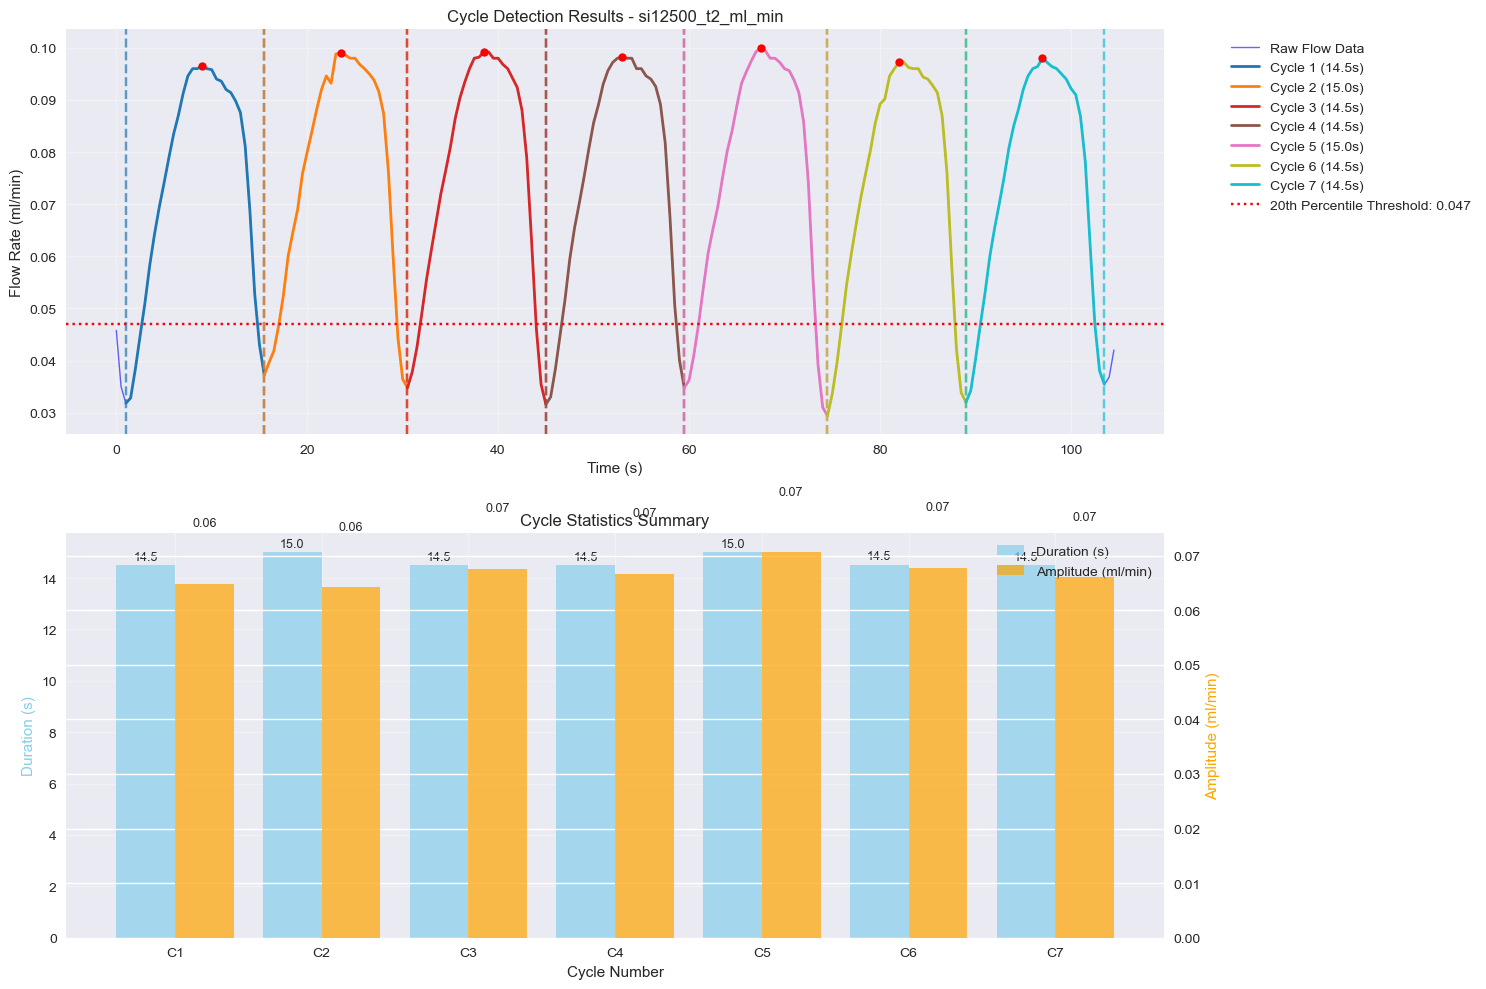

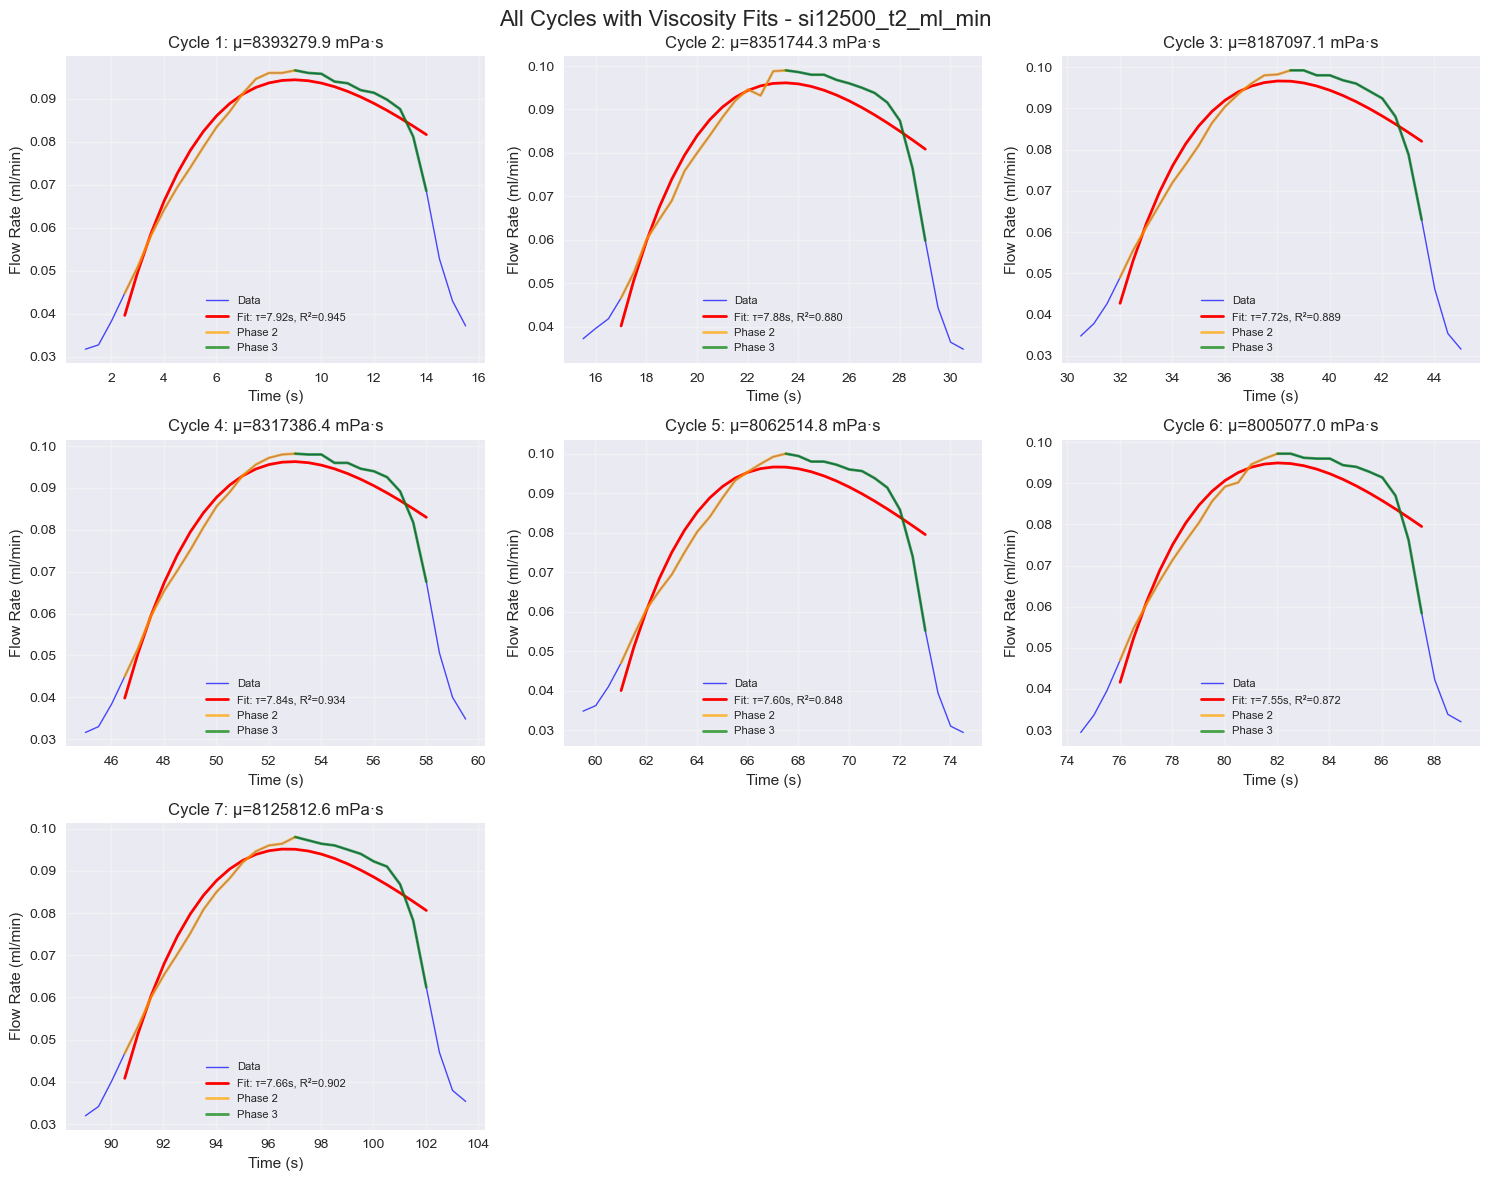


📊 Viscosity Results Summary for si12500_t2_ml_min
 Cycle Duration (s) Amplitude (ml/min) τ (s) μ (mPa·s)    R²
     1        14.50              0.065  7.92 8393279.9 0.945
     2        15.00              0.064  7.88 8351744.3 0.880
     3        14.50              0.068  7.72 8187097.1 0.889
     4        14.50              0.067  7.84 8317386.4 0.934
     5        15.00              0.071  7.60 8062514.8 0.848
     6        14.51              0.068  7.55 8005077.0 0.872
     7        14.50              0.066  7.66 8125812.6 0.902

📈 Statistics:
   Valid measurements: 7/7 cycles
   Mean viscosity: 8206130.3 ± 139625.7 mPa·s
   Range: 8005077.0 - 8393279.9 mPa·s
   CV: 1.7%
✅ Generated 2 visualization panels

📋 Summary of all 7 detected cycles:
 Cycle  Start Time (s)  Duration (s)  Peak Flow (ml/min)  Amplitude (ml/min)  Data Points
     1           1.007        14.502               0.097               0.065           30
     2          15.509        15.005               0.099        

In [394]:
# Create comprehensive visualizations of the enhanced analysis
if analysis_results:
    print("🎨 Creating Enhanced Analysis Visualizations")
    print("=" * 50)
    
    figures = rheometer.create_comprehensive_visualization(analysis_results, show_plots=True)
    
    print(f"✅ Generated {len(figures)} visualization panels")
    
    # Display summary table of all detected cycles
    all_cycles = analysis_results['cycle_detection']['all_cycles']  # Fixed path
    if len(all_cycles) > 1:
        print(f"\n📋 Summary of all {len(all_cycles)} detected cycles:")
        
        cycle_summary = []
        for i, cycle in enumerate(all_cycles):
            cycle_summary.append({
                'Cycle': i + 1,
                'Start Time (s)': cycle['start_time'],
                'Duration (s)': cycle['duration'],
                'Peak Flow (ml/min)': cycle['peak_flow'],
                'Amplitude (ml/min)': cycle['amplitude'],
                'Data Points': cycle['data_points']
            })
        
        cycle_summary_df = pd.DataFrame(cycle_summary)
        
        # Display the table
        print(cycle_summary_df.to_string(index=False, float_format='%.3f'))
        
        # Show statistics across all cycles
        print(f"\n📊 Statistics across all cycles:")
        print(f"   Average duration: {np.mean([c['duration'] for c in all_cycles]):.2f} ± {np.std([c['duration'] for c in all_cycles]):.2f} s")
        print(f"   Average amplitude: {np.mean([c['amplitude'] for c in all_cycles]):.4f} ± {np.std([c['amplitude'] for c in all_cycles]):.4f} ml/min")
        print(f"   Average peak flow: {np.mean([c['peak_flow'] for c in all_cycles]):.4f} ± {np.std([c['peak_flow'] for c in all_cycles]):.4f} ml/min")
        
else:
    print("❌ No analysis results available for visualization")

In [395]:
# 🚀 COMPREHENSIVE ANALYSIS: All Samples
print("🚀 Running Comprehensive Analysis on All Samples")
print("=" * 80)

# Define all samples to analyze
all_samples = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min'
]

# Initialize comprehensive dataset
comprehensive_dataset = []
all_sample_results = {}

# Process each sample
for sample_name in all_samples:
    print(f"\n🔬 Processing {sample_name}...")
    
    try:
        # Get data for this sample
        time_data = df['time_s'].values
        flow_data = df[sample_name].values
        
        # Run analysis
        sample_results = rheometer.analyze_all_cycles(time_data, flow_data, sample_name, enable_filtering=False)
        
        if sample_results:
            all_sample_results[sample_name] = sample_results
            
            # Extract data for each cycle
            cycle_analyses = sample_results['cycle_analyses']
            
            for cycle_analysis in cycle_analyses:
                cycle_num = cycle_analysis['cycle_number']
                viscosity_fit = cycle_analysis['viscosity_fit']
                
                if viscosity_fit and not np.isnan(viscosity_fit['tau']):
                    # Convert viscosity to cP (1 Pa·s = 1000 cP)
                    viscosity_cP = cycle_analysis['viscosity_mPa_s']
                    
                    row_data = {
                        'sample_name': sample_name,
                        'cycle_number': cycle_num,
                        'A': viscosity_fit['A'],
                        'B': viscosity_fit['B'],
                        'tau': viscosity_fit['tau'],
                        'R2': viscosity_fit['r_squared'],
                        'viscosity_cP': viscosity_cP
                    }
                    
                    comprehensive_dataset.append(row_data)
                    
            print(f"   ✅ Successfully analyzed {len(cycle_analyses)} cycles")
        else:
            print(f"   ❌ Failed to analyze {sample_name}")
            
    except Exception as e:
        print(f"   ❌ Error processing {sample_name}: {e}")

# Create comprehensive DataFrame
df_comprehensive = pd.DataFrame(comprehensive_dataset)

print(f"\n📊 Comprehensive Dataset Created:")
print(f"   Total samples: {len(all_samples)}")
print(f"   Successfully analyzed: {len(all_sample_results)}")
print(f"   Total cycles analyzed: {len(df_comprehensive)}")
print(f"   Variables: {list(df_comprehensive.columns)}")

# Display first few rows
print(f"\n📋 Sample of the dataset:")
print(df_comprehensive.head(10).to_string(index=False, float_format='%.3f'))

# Add sample type categorization
def categorize_sample(sample_name):
    if 'water' in sample_name:
        return 'Water'
    elif 'si350' in sample_name:
        return 'Si-350cP'
    elif 'si1000' in sample_name:
        return 'Si-1000cP'  
    elif 'si5000' in sample_name:
        return 'Si-5000cP'
    elif 'si12500' in sample_name:
        return 'Si-12500cP'
    else:
        return 'Unknown'

df_comprehensive['sample_type'] = df_comprehensive['sample_name'].apply(categorize_sample)

print("✅ Comprehensive analysis completed!")

🚀 Running Comprehensive Analysis on All Samples

🔬 Processing water_b1_ml_min...
Analyzing 6 cycles for water_b1_ml_min
  Processing cycle 1/6...
  Processing cycle 2/6...
  Processing cycle 3/6...
  Processing cycle 4/6...
  Processing cycle 5/6...
  Processing cycle 6/6...
   ✅ Successfully analyzed 6 cycles

🔬 Processing water_b2_ml_min...
Analyzing 7 cycles for water_b2_ml_min
  Processing cycle 1/7...
  Processing cycle 2/7...
  Processing cycle 3/7...
  Processing cycle 4/7...
  Processing cycle 5/7...
  Processing cycle 6/7...
  Processing cycle 7/7...
   ✅ Successfully analyzed 7 cycles

🔬 Processing water_b3_ml_min...
Analyzing 6 cycles for water_b3_ml_min
  Processing cycle 1/6...
  Processing cycle 2/6...
  Processing cycle 3/6...
  Processing cycle 4/6...
  Processing cycle 5/6...
  Processing cycle 6/6...
   ✅ Successfully analyzed 6 cycles

🔬 Processing si350_t1_ml_min...
Analyzing 6 cycles for si350_t1_ml_min
  Processing cycle 1/6...
  Processing cycle 2/6...
  Processi

📊 Creating Comprehensive Variable Comparisons


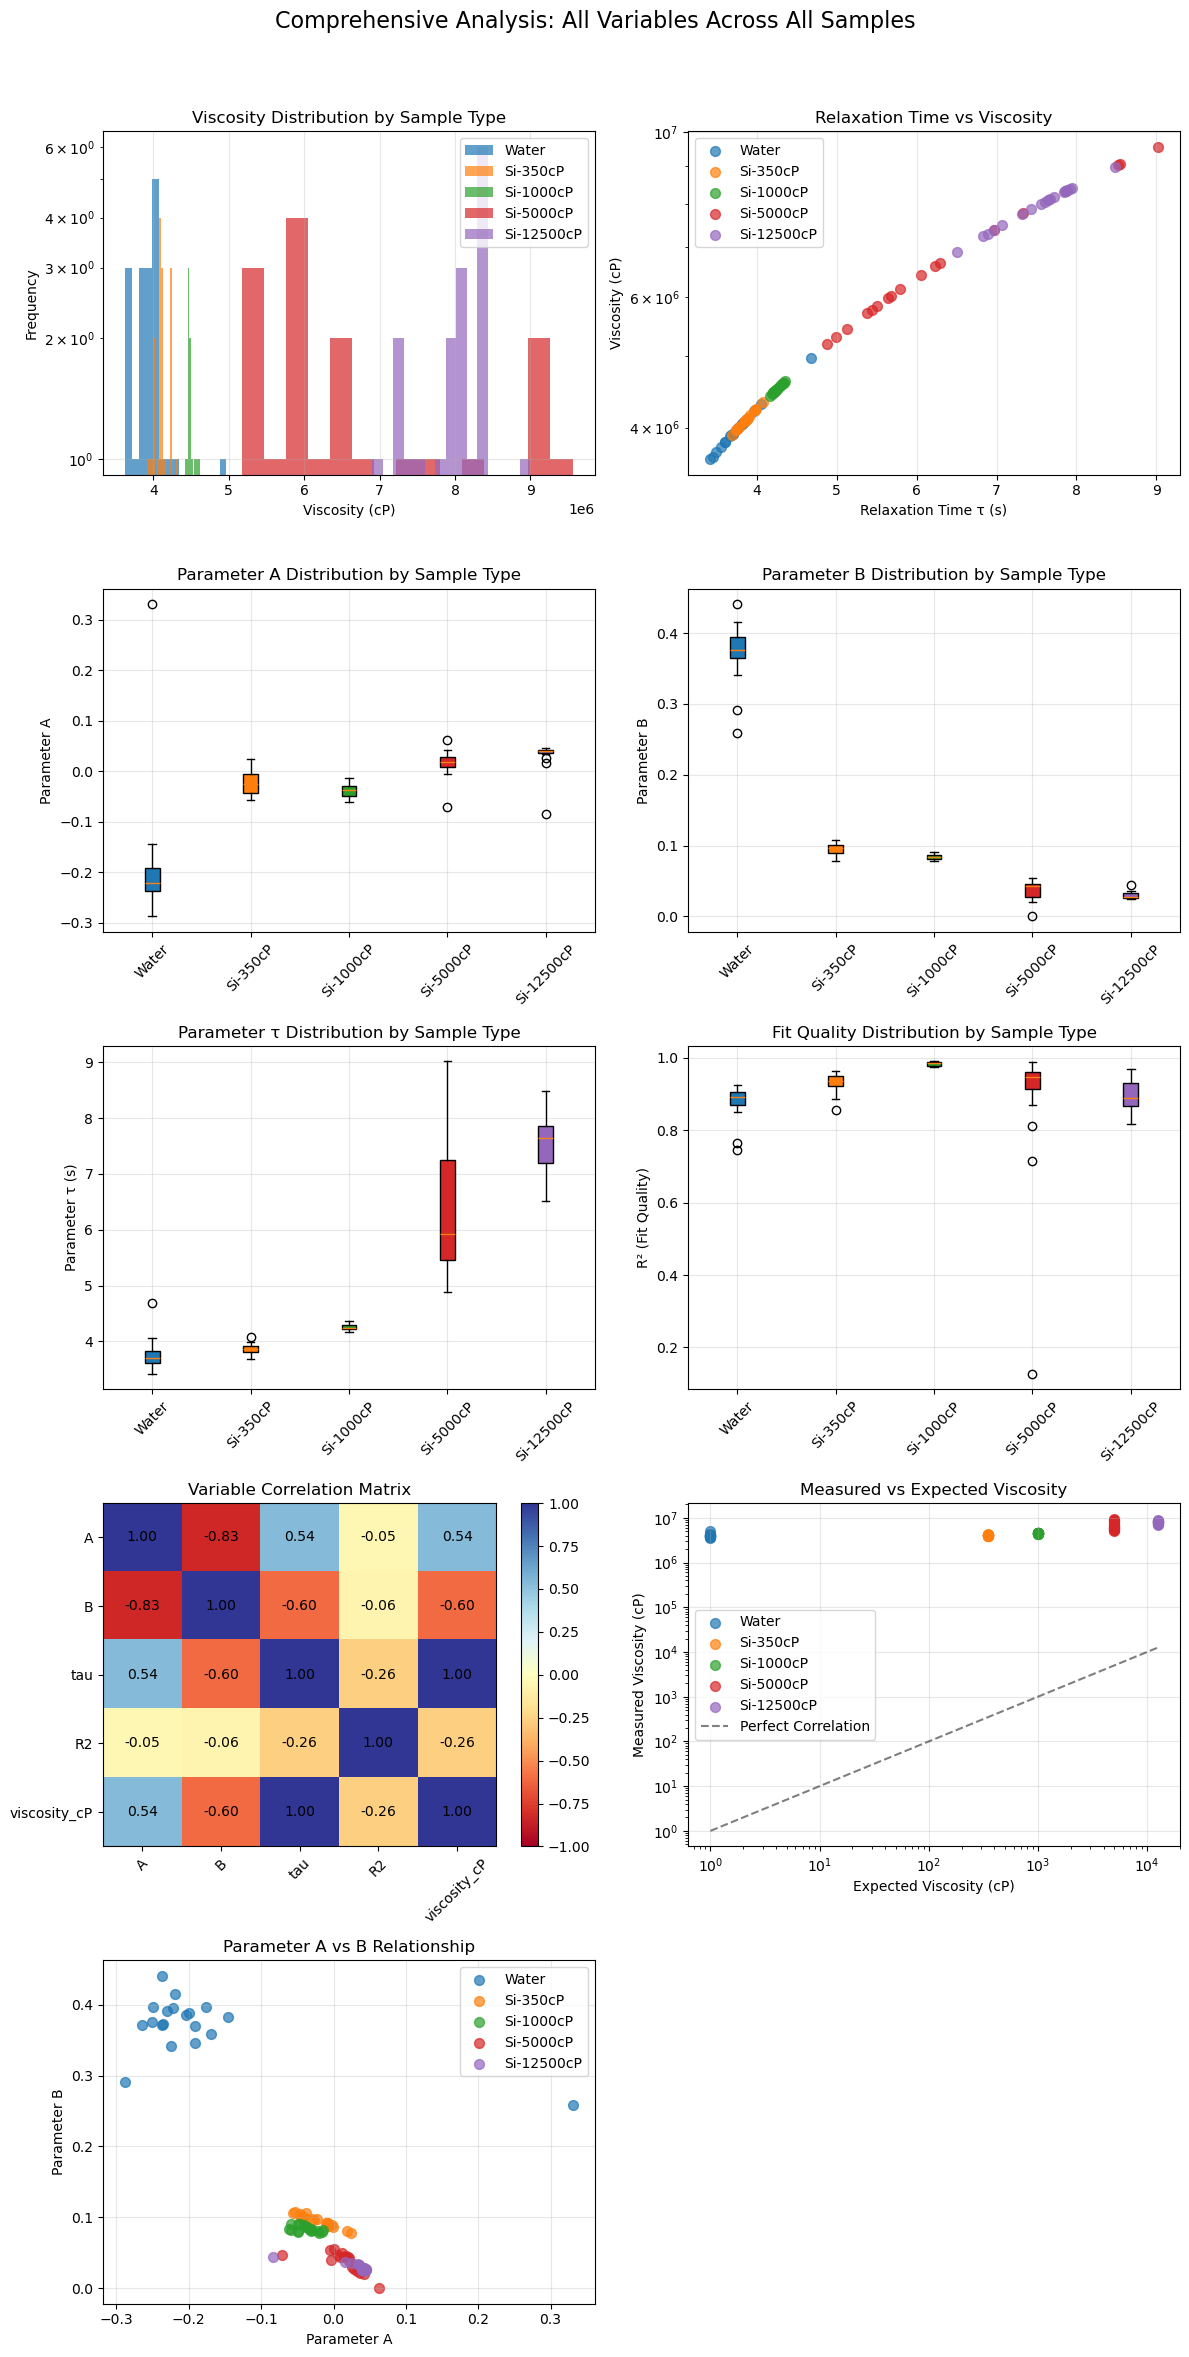

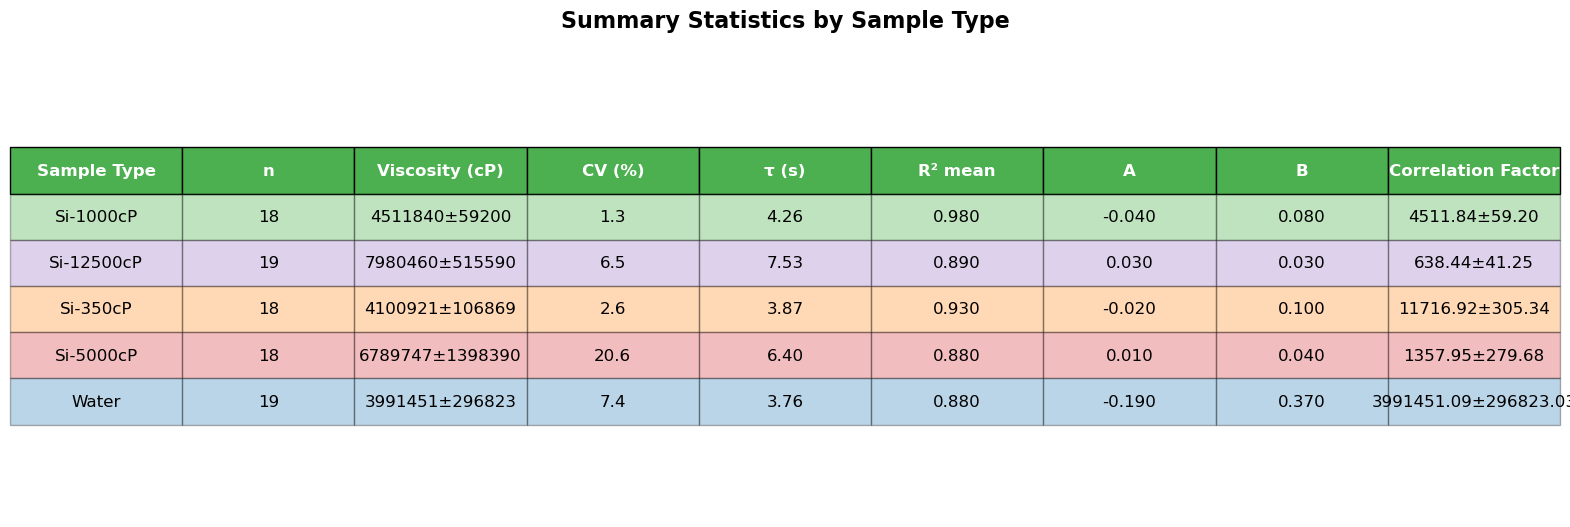

✅ Comprehensive visualization completed!

📈 Overall Dataset Statistics:
   Total measurements: 92
   Mean fit quality (R²): 0.912
   Viscosity range: 3628019.8 - 9558642.5 cP
   τ range: 3.42 - 9.02 s
💾 Dataset saved as 'comprehensive_viscosity_analysis.csv'


In [400]:
# 📊 COMPREHENSIVE VISUALIZATION: Variable Comparison
print("📊 Creating Comprehensive Variable Comparisons")
print("=" * 60)

# Set up the plotting style
plt.style.use('default')
fig = plt.figure(figsize=(12, 24))

# Color mapping for sample types
type_colors = {
    'Water': '#1f77b4',
    'Si-350cP': '#ff7f0e', 
    'Si-1000cP': '#2ca02c',
    'Si-5000cP': '#d62728',
    'Si-12500cP': '#9467bd'
}

# 1. Viscosity Distribution by Sample Type
ax1 = plt.subplot(5, 2, 1)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]['viscosity_cP']
    ax1.hist(data, alpha=0.7, label=sample_type, color=type_colors[sample_type], bins=15)
ax1.set_xlabel('Viscosity (cP)')
ax1.set_ylabel('Frequency')
ax1.set_title('Viscosity Distribution by Sample Type')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 2. Relaxation Time vs Viscosity
ax2 = plt.subplot(5, 2, 2)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]
    ax2.scatter(data['tau'], data['viscosity_cP'], alpha=0.7, 
               label=sample_type, color=type_colors[sample_type], s=50)
ax2.set_xlabel('Relaxation Time τ (s)')
ax2.set_ylabel('Viscosity (cP)')
ax2.set_title('Relaxation Time vs Viscosity')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# 3. Parameter A Distribution
ax3 = plt.subplot(5, 2, 3)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]['A']
    ax3.boxplot(data, positions=[list(df_comprehensive['sample_type'].unique()).index(sample_type)],
               patch_artist=True, boxprops=dict(facecolor=type_colors[sample_type]))
ax3.set_xticks(range(len(df_comprehensive['sample_type'].unique())))
ax3.set_xticklabels(df_comprehensive['sample_type'].unique(), rotation=45)
ax3.set_ylabel('Parameter A')
ax3.set_title('Parameter A Distribution by Sample Type')
ax3.grid(True, alpha=0.3)

# 4. Parameter B Distribution  
ax4 = plt.subplot(5, 2, 4)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]['B']
    ax4.boxplot(data, positions=[list(df_comprehensive['sample_type'].unique()).index(sample_type)],
               patch_artist=True, boxprops=dict(facecolor=type_colors[sample_type]))
ax4.set_xticks(range(len(df_comprehensive['sample_type'].unique())))
ax4.set_xticklabels(df_comprehensive['sample_type'].unique(), rotation=45)
ax4.set_ylabel('Parameter B')
ax4.set_title('Parameter B Distribution by Sample Type')
ax4.grid(True, alpha=0.3)

# 5. Parameter τ (Tau) Distribution
ax5 = plt.subplot(5, 2, 5)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]['tau']
    ax5.boxplot(data, positions=[list(df_comprehensive['sample_type'].unique()).index(sample_type)],
               patch_artist=True, boxprops=dict(facecolor=type_colors[sample_type]))
ax5.set_xticks(range(len(df_comprehensive['sample_type'].unique())))
ax5.set_xticklabels(df_comprehensive['sample_type'].unique(), rotation=45)
ax5.set_ylabel('Parameter τ (s)')
ax5.set_title('Parameter τ Distribution by Sample Type')
ax5.grid(True, alpha=0.3)

# 6. R² (Fit Quality) Distribution
ax6 = plt.subplot(5, 2, 6)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]['R2']
    ax6.boxplot(data, positions=[list(df_comprehensive['sample_type'].unique()).index(sample_type)],
               patch_artist=True, boxprops=dict(facecolor=type_colors[sample_type]))
ax6.set_xticks(range(len(df_comprehensive['sample_type'].unique())))
ax6.set_xticklabels(df_comprehensive['sample_type'].unique(), rotation=45)
ax6.set_ylabel('R² (Fit Quality)')
ax6.set_title('Fit Quality Distribution by Sample Type')
ax6.grid(True, alpha=0.3)

# 7. Correlation Matrix
ax7 = plt.subplot(5, 2, 7)
numerical_cols = ['A', 'B', 'tau', 'R2', 'viscosity_cP']
corr_matrix = df_comprehensive[numerical_cols].corr()
im = ax7.imshow(corr_matrix, cmap='RdYlBu', aspect='auto', vmin=-1, vmax=1)
ax7.set_xticks(range(len(numerical_cols)))
ax7.set_yticks(range(len(numerical_cols)))
ax7.set_xticklabels(numerical_cols, rotation=45)
ax7.set_yticklabels(numerical_cols)
ax7.set_title('Variable Correlation Matrix')
# Add correlation values as text
for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        ax7.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax7)

# 8. Viscosity vs Expected (Nominal) Values
ax8 = plt.subplot(5, 2, 8)
# Extract expected viscosity from sample type
expected_viscosity = {
    'Water': 1,
    'Si-350cP': 350,
    'Si-1000cP': 1000,
    'Si-5000cP': 5000,
    'Si-12500cP': 12500
}
df_comprehensive['expected_viscosity'] = df_comprehensive['sample_type'].map(expected_viscosity)

for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]
    ax8.scatter(data['expected_viscosity'], data['viscosity_cP'], 
               alpha=0.7, label=sample_type, color=type_colors[sample_type], s=50)

# Add perfect correlation line
x_range = [df_comprehensive['expected_viscosity'].min(), df_comprehensive['expected_viscosity'].max()]
ax8.plot(x_range, x_range, 'k--', alpha=0.5, label='Perfect Correlation')
ax8.set_xlabel('Expected Viscosity (cP)')
ax8.set_ylabel('Measured Viscosity (cP)')
ax8.set_title('Measured vs Expected Viscosity')
ax8.legend()
ax8.grid(True, alpha=0.3)
ax8.set_xscale('log')
ax8.set_yscale('log')

# 9. Parameter A vs B Relationship
ax9 = plt.subplot(5, 2, 9)
for sample_type in df_comprehensive['sample_type'].unique():
    data = df_comprehensive[df_comprehensive['sample_type'] == sample_type]
    ax9.scatter(data['A'], data['B'], alpha=0.7, 
               label=sample_type, color=type_colors[sample_type], s=50)
ax9.set_xlabel('Parameter A')
ax9.set_ylabel('Parameter B') 
ax9.set_title('Parameter A vs B Relationship')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Analysis: All Variables Across All Samples', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Create a separate wide figure for the summary table
fig_table = plt.figure(figsize=(20, 6))
ax_table = plt.subplot(1, 1, 1)
ax_table.axis('off')

# Calculate summary statistics by sample type
summary_stats = df_comprehensive.groupby('sample_type').agg({
    'viscosity_cP': ['mean', 'std', 'count'],
    'tau': ['mean', 'std'],
    'R2': ['mean', 'min'],
    'A': 'mean',
    'B': 'mean'
}).round(2)

# Calculate correlation factors (measured/expected viscosity)
df_comprehensive['correlation_factor'] = df_comprehensive['viscosity_cP'] / df_comprehensive['expected_viscosity']
correlation_stats = df_comprehensive.groupby('sample_type')['correlation_factor'].agg(['mean', 'std']).round(3)

# Create summary table data with correlation factor
table_data = [['Sample Type', 'n', 'Viscosity (cP)', 'CV (%)', 'τ (s)', 'R² mean', 'A', 'B', 'Correlation Factor']]

for sample_type in summary_stats.index:
    visc_mean = summary_stats.loc[sample_type, ('viscosity_cP', 'mean')]
    visc_std = summary_stats.loc[sample_type, ('viscosity_cP', 'std')]
    cv = (visc_std / visc_mean * 100) if visc_mean > 0 else 0
    count = int(summary_stats.loc[sample_type, ('viscosity_cP', 'count')])
    tau_mean = summary_stats.loc[sample_type, ('tau', 'mean')]
    r2_mean = summary_stats.loc[sample_type, ('R2', 'mean')]
    a_mean = summary_stats.loc[sample_type, ('A', 'mean')]
    b_mean = summary_stats.loc[sample_type, ('B', 'mean')]
    corr_factor_mean = correlation_stats.loc[sample_type, 'mean']
    corr_factor_std = correlation_stats.loc[sample_type, 'std']
    
    table_data.append([
        sample_type, 
        f'{count}',
        f'{visc_mean:.0f}±{visc_std:.0f}',
        f'{cv:.1f}',
        f'{tau_mean:.2f}',
        f'{r2_mean:.3f}',
        f'{a_mean:.3f}',
        f'{b_mean:.3f}',
        f'{corr_factor_mean:.2f}±{corr_factor_std:.2f}'
    ])

# Create table
table = ax_table.table(cellText=table_data[1:], colLabels=table_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0.2, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

# Style the table
for i in range(len(table_data)):
    for j in range(len(table_data[0])):
        if i == 0:  # Header
            table[(i, j)].set_facecolor('#4CAF50')
            table[(i, j)].set_text_props(weight='bold', color='white')
        else:
            sample_type = table_data[i][0] if i > 0 else None
            if sample_type in type_colors:
                table[(i, j)].set_facecolor(type_colors[sample_type])
                table[(i, j)].set_alpha(0.3)

ax_table.set_title('Summary Statistics by Sample Type', pad=20, fontweight='bold', fontsize=16)

plt.show()

print("✅ Comprehensive visualization completed!")

# Display overall statistics
print(f"\n📈 Overall Dataset Statistics:")
print(f"   Total measurements: {len(df_comprehensive)}")
print(f"   Mean fit quality (R²): {df_comprehensive['R2'].mean():.3f}")
print(f"   Viscosity range: {df_comprehensive['viscosity_cP'].min():.1f} - {df_comprehensive['viscosity_cP'].max():.1f} cP")
print(f"   τ range: {df_comprehensive['tau'].min():.2f} - {df_comprehensive['tau'].max():.2f} s")

# Save comprehensive dataset
df_comprehensive.to_csv('comprehensive_viscosity_analysis.csv', index=False)
print(f"💾 Dataset saved as 'comprehensive_viscosity_analysis.csv'")

📊 Creating Dual Y-Axis Bar Plots
Data Summary for Bar Plots:
  sample_type    tau  viscosity_cP      B  expected_viscosity
0       Water  3.764   3991451.089  0.371                   1
1    Si-350cP  3.868   4100920.962  0.095                 350
2   Si-1000cP  4.255   4511839.678  0.084                1000
3   Si-5000cP  6.404   6789747.477  0.037                5000
4  Si-12500cP  7.527   7980460.484  0.030               12500


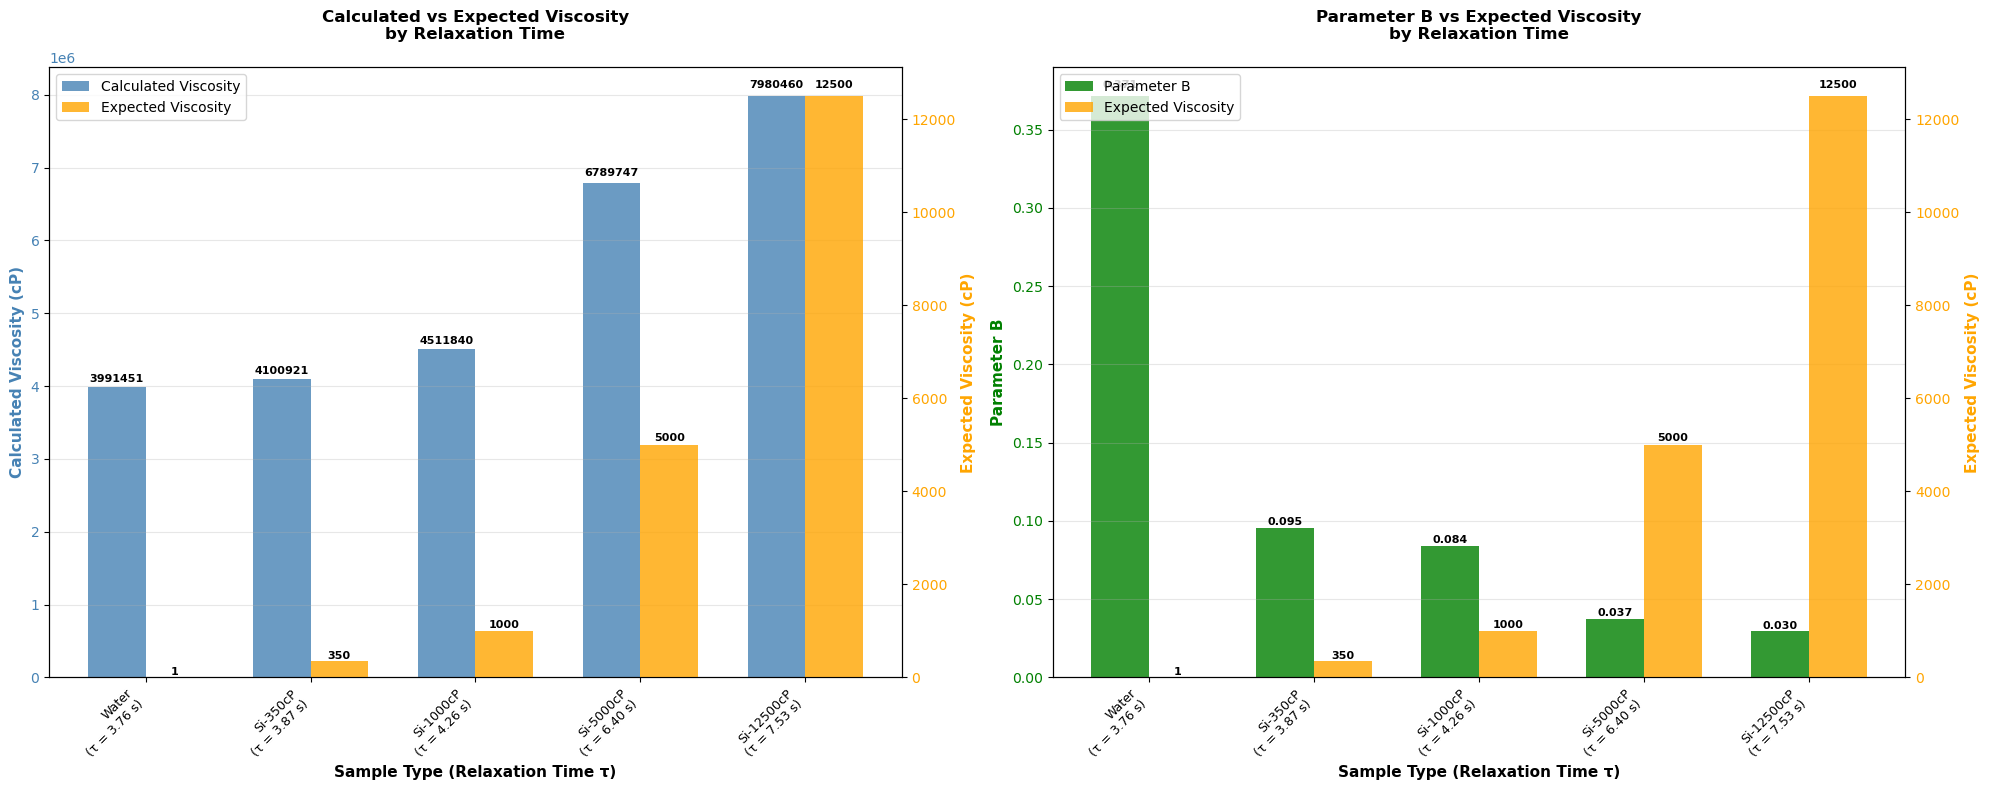


📋 Summary Table: Calculated Viscosity vs Expected Viscosity
sample_type  tau  viscosity_cP  expected_viscosity  Accuracy (%)    Error (%)
      Water 3.76    3991451.09                   1  399145108.93 399145008.93
   Si-350cP 3.87    4100920.96                 350    1171691.70   1171591.70
  Si-1000cP 4.26    4511839.68                1000     451183.97    451083.97
  Si-5000cP 6.40    6789747.48                5000     135794.95    135694.95
 Si-12500cP 7.53    7980460.48               12500      63843.68     63743.68

📈 Viscosity Performance:
   Mean Accuracy: 80193524.6%
   Mean Absolute Error: 80193424.6%

📋 Summary Table: Parameter B vs Relaxation Time
sample_type   tau     B  expected_viscosity
      Water 3.764 0.371                   1
   Si-350cP 3.868 0.095                 350
  Si-1000cP 4.255 0.084                1000
  Si-5000cP 6.404 0.037                5000
 Si-12500cP 7.527 0.030               12500

🏆 Best Viscosity Performance: Si-12500cP (63743.7% error)
⚠️  Wor

In [398]:
# 📊 DUAL Y-AXIS BAR PLOTS: Viscosity & Parameter B vs Expected Values by Relaxation Time
print("📊 Creating Dual Y-Axis Bar Plots")
print("=" * 60)

# Prepare data for plotting
# Group by sample type and calculate mean values for visualization
plot_data = df_comprehensive.groupby('sample_type').agg({
    'tau': 'mean',
    'viscosity_cP': 'mean',
    'B': 'mean',  # Add Parameter B
    'expected_viscosity': 'first'  # Expected is the same for all samples of same type
}).reset_index()

# Sort by expected viscosity for better visualization
plot_data = plot_data.sort_values('expected_viscosity').reset_index(drop=True)

print("Data Summary for Bar Plots:")
print(plot_data[['sample_type', 'tau', 'viscosity_cP', 'B', 'expected_viscosity']].round(3))

# Create subplots: 1 row, 2 columns
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(20, 8))

# Define positions and width for bars
x_pos = np.arange(len(plot_data))
width = 0.35

# ========== PLOT 1: Calculated Viscosity vs Expected Viscosity ==========
# Plot calculated viscosity on left y-axis
bars1_visc = ax1.bar(x_pos - width/2, plot_data['viscosity_cP'], width, 
                     label='Calculated Viscosity', color='steelblue', alpha=0.8)

# Create second y-axis for expected viscosity
ax2 = ax1.twinx()

# Plot expected viscosity on right y-axis
bars2_visc = ax2.bar(x_pos + width/2, plot_data['expected_viscosity'], width, 
                     label='Expected Viscosity', color='orange', alpha=0.8)

# Set x-axis labels (relaxation time values)
ax1.set_xlabel('Sample Type (Relaxation Time τ)', fontsize=11, fontweight='bold')
ax1.set_xticks(x_pos)
x_labels = [f"{row['sample_type']}\n(τ = {row['tau']:.2f} s)" 
           for _, row in plot_data.iterrows()]
ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)

# Set y-axis labels
ax1.set_ylabel('Calculated Viscosity (cP)', fontsize=11, fontweight='bold', color='steelblue')
ax2.set_ylabel('Expected Viscosity (cP)', fontsize=11, fontweight='bold', color='orange')

# Color the y-axis labels to match the data
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='orange')

# Set title
ax1.set_title('Calculated vs Expected Viscosity\nby Relaxation Time', 
              fontsize=12, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1_visc, bars2_visc)):
    # Labels for calculated viscosity (left axis)
    height1 = bar1.get_height()
    ax1.text(bar1.get_x() + bar1.get_width()/2., height1 + height1*0.01,
             f'{height1:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Labels for expected viscosity (right axis) 
    height2 = bar2.get_height()
    ax2.text(bar2.get_x() + bar2.get_width()/2., height2 + height2*0.01,
             f'{height2:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add grid for better readability
ax1.grid(True, alpha=0.3, axis='y')

# Create combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# ========== PLOT 2: Parameter B vs Expected Viscosity ==========
# Plot Parameter B on left y-axis
bars1_B = ax3.bar(x_pos - width/2, plot_data['B'], width, 
                  label='Parameter B', color='green', alpha=0.8)

# Create second y-axis for expected viscosity
ax4 = ax3.twinx()

# Plot expected viscosity on right y-axis
bars2_B = ax4.bar(x_pos + width/2, plot_data['expected_viscosity'], width, 
                  label='Expected Viscosity', color='orange', alpha=0.8)

# Set x-axis labels (relaxation time values)
ax3.set_xlabel('Sample Type (Relaxation Time τ)', fontsize=11, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)

# Set y-axis labels
ax3.set_ylabel('Parameter B', fontsize=11, fontweight='bold', color='green')
ax4.set_ylabel('Expected Viscosity (cP)', fontsize=11, fontweight='bold', color='orange')

# Color the y-axis labels to match the data
ax3.tick_params(axis='y', labelcolor='green')
ax4.tick_params(axis='y', labelcolor='orange')

# Set title
ax3.set_title('Parameter B vs Expected Viscosity\nby Relaxation Time', 
              fontsize=12, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1_B, bars2_B)):
    # Labels for Parameter B (left axis)
    height1 = bar1.get_height()
    ax3.text(bar1.get_x() + bar1.get_width()/2., height1 + abs(height1)*0.01,
             f'{height1:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Labels for expected viscosity (right axis) 
    height2 = bar2.get_height()
    ax4.text(bar2.get_x() + bar2.get_width()/2., height2 + height2*0.01,
             f'{height2:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add grid for better readability
ax3.grid(True, alpha=0.3, axis='y')

# Create combined legend
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=10)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plots
plt.show()

# Create summary tables showing the comparisons
print(f"\n📋 Summary Table: Calculated Viscosity vs Expected Viscosity")
print("=" * 80)

comparison_table_visc = plot_data.copy()
comparison_table_visc['Accuracy (%)'] = (comparison_table_visc['viscosity_cP'] / comparison_table_visc['expected_viscosity'] * 100)
comparison_table_visc['Error (%)'] = abs(comparison_table_visc['Accuracy (%)'] - 100)

display_cols_visc = ['sample_type', 'tau', 'viscosity_cP', 'expected_viscosity', 'Accuracy (%)', 'Error (%)']
comparison_display_visc = comparison_table_visc[display_cols_visc].round(2)

print(comparison_display_visc.to_string(index=False))

# Calculate overall statistics for viscosity
overall_accuracy_visc = np.mean(comparison_table_visc['Accuracy (%)'])
overall_error_visc = np.mean(comparison_table_visc['Error (%)'])

print(f"\n📈 Viscosity Performance:")
print(f"   Mean Accuracy: {overall_accuracy_visc:.1f}%")
print(f"   Mean Absolute Error: {overall_error_visc:.1f}%")

print(f"\n📋 Summary Table: Parameter B vs Relaxation Time")
print("=" * 60)

display_cols_B = ['sample_type', 'tau', 'B', 'expected_viscosity']
comparison_display_B = plot_data[display_cols_B].round(3)

print(comparison_display_B.to_string(index=False))

# Identify best and worst performing samples for viscosity
best_sample_visc = comparison_table_visc.loc[comparison_table_visc['Error (%)'].idxmin(), 'sample_type']
worst_sample_visc = comparison_table_visc.loc[comparison_table_visc['Error (%)'].idxmax(), 'sample_type']

print(f"\n🏆 Best Viscosity Performance: {best_sample_visc} ({comparison_table_visc.loc[comparison_table_visc['sample_type']==best_sample_visc, 'Error (%)'].iloc[0]:.1f}% error)")
print(f"⚠️  Worst Viscosity Performance: {worst_sample_visc} ({comparison_table_visc.loc[comparison_table_visc['sample_type']==worst_sample_visc, 'Error (%)'].iloc[0]:.1f}% error)")

print(f"\n✅ Dual y-axis bar plots completed!")